# ASKAP Holography HDF5 Analysis
## Per-antenna beam characterisation — SB82194

This notebook mirrors the FITS-based `holopy_demo.ipynb` but operates directly on the
**native HDF5 pipeline products** where the full antenna dimension is preserved.

### Key difference from the FITS analysis

| Aspect | FITS (`holopy_demo`) | HDF5 (this notebook) |
|---|---|---|
| Pixel grid | 101 × 101 (WCS, arcmin) | 15 × 15 (holography grid, radians) |
| Antenna axis | Collapsed (not in file) | Full: 36 antennas retained |
| Polarisations | Stokes IQUV (real, float) | Raw XX/XY/YX/YY (complex) **and** Stokes IQUV (float) |
| Flags | NaN masking only | Explicit boolean flag dataset |
| Data type | float32 | complex64 (raw) / float64 (Stokes) |

### HDF5 files used
| File | Shape | Content |
|---|---|---|
| `*.xxyy…hdf5` | `(1, 36 ant, 36 beam, 4 pol, 288 freq, 15, 15)` | Raw complex XX/XY/YX/YY cross-correlations |
| `*.stokes…hdf5` | `(1, 36 ant, 36 beam, 4 pol, 288 freq, 15, 15)` | Normalised Stokes IQUV (float64) |

Axis order in memory (after loading): `[time, antenna, beam, pol, freq, y, x]`

### Analysis sections
1. Imports & file paths
2. Load & inspect HDF5 structure
3. Flag statistics
4. Global statistics (alive check)
5. Cross-channel consistency per antenna
6. Per-antenna beam maps — all beams, single Stokes
7. Antenna–beam amplitude matrix (heatmap)
8. FWHM estimation across antennas
9. Centroid offsets across antennas
10. Stokes IQUV panels per antenna
11. Frequency spectra per antenna
12. Channel flagging per antenna
13. Antenna-to-antenna difference maps
14. Cross-antenna outlier detection
15. Raw XX/YY — amplitude and phase inspection

## 1. Imports & File Paths

Sets up the Python environment and declares the paths to both HDF5 data files.

**Libraries used:**

| Library | Purpose |
|---|---|
| `numpy` | Array arithmetic, NaN-safe statistics, percentile calculations |
| `h5py` | Reading ASKAP holography HDF5 files directly without loading the full XXYY file into memory |
| `matplotlib` | All 2-D/1-D visualisation |
| `scipy.ndimage.center_of_mass` | Intensity-weighted centroid calculation (Section 9) |
| `scipy.optimize.curve_fit` | Reserved for Gaussian profile fitting extensions |

**Files used:**

| Variable | File pattern | Size | Content |
|---|---|---|---|
| `XXYY_FILE` | `*.xxyy…hdf5` | ~2.8 GB | Raw complex cross-correlations XX/XY/YX/YY (complex64) |
| `STOKES_FILE` | `*.stokes…hdf5` | ~2.5 GB | Normalised Stokes IQUV (float64, derived from XXYY by the holography pipeline) |

**What to check:**
- Both file sizes print without error — confirms the files are present and accessible on this machine.
- A `FileNotFoundError` here means `DATA_DIR` needs updating to match your local path.
- `matplotlib.rcParams["figure.dpi"] = 120` sets higher-resolution inline plots; lower this if rendering is slow.


In [1]:
import sys, os
import numpy as np
import h5py
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import center_of_mass
from scipy.optimize import curve_fit

DATA_DIR = "/Users/raj030/DATA/askap-beam-analysis"

XXYY_FILE   = os.path.join(DATA_DIR, "akpb.xxyy.closepack36.54.943MHz.SB82194.hdf5")
STOKES_FILE = os.path.join(DATA_DIR, "akpb.iquv.closepack36.54.943MHz.SB82194.stokes.hdf5")

print("Imports OK")
for f in [XXYY_FILE, STOKES_FILE]:
    size_gb = os.path.getsize(f) / 1e9
    print(f"  {os.path.basename(f)}  ({size_gb:.2f} GB)")

Imports OK
  akpb.xxyy.closepack36.54.943MHz.SB82194.hdf5  (3.02 GB)
  akpb.iquv.closepack36.54.943MHz.SB82194.stokes.hdf5  (2.69 GB)


## 2. Load & Inspect HDF5 Structure

Loads the Stokes HDF5 file entirely into RAM and extracts all axis metadata from the `data` dataset attributes. The raw XXYY file is opened lazily — only slices are read as needed in Section 15.

### HDF5 internal schema

Both files share the same layout:

| Dataset | Shape | dtype | Content |
|---|---|---|---|
| `/data` | `(1, 36, 36, 4, 288, 15, 15)` | float64 / complex64 | Beam measurements |
| `/flags` | `(1, 36, 36, 4, 288)` | bool | Per-channel flag mask (no spatial axes) |

After dropping the time axis (`[0]` indexing) the working shape in memory is `(ant, beam, pol, freq, y, x)`.

### Axis metadata attributes on `/data`

| Attribute | Shape | Units | Description |
|---|---|---|---|
| `frequencies` | `(288,)` | MHz | Centre frequency of each channel (~800–1087 MHz) |
| `antennas` | `(36,)` | 1-based int | ASKAP antenna numbers present in the file |
| `beams` | `(36,)` | 1-based int | Formed beam numbers in the closepack-36 footprint |
| `polarizations` | `(4,)` | string | `['I','Q','U','V']` for Stokes; `['XX','XY','YX','YY']` for raw |
| `xAxis` / `yAxis` | `(15,)` | radians | Holography grid sample positions on sky |

### Spatial grid

The 15 × 15 grid covers ±4.2° (±0.073 rad) on each axis, giving a pixel scale of ~0.6°/pixel. This is much coarser than the FITS cube (101 × 101 at ~2′/pixel) because the holography measurements are taken at a discrete grid of sky positions during the observation.

### Missing antennas

Not all 36 antenna slots are populated — some antennas were not included in SB82194. The following 0-based antenna **indices** contain only NaN:

| Index | Antenna number |
|---|---|
| 0 | 1 |
| 2 | 3 |
| 6 | 7 |
| 9 | 10 |
| 18 | 19 |

All other 31 antenna indices contain valid data. Cells that accept `ANT_IDX` as input include a reminder comment listing these invalid indices.

**What to check:**
- `Stokes data shape` should print `(36, 36, 4, 288, 15, 15)`.
- Frequency range should span ~800–1087 MHz (288 channels, ~1 MHz spacing).
- Spatial FOV should print ~8.4° (difference between max and min of `xAxis` in degrees).
- `Flags shape` should be `(36, 36, 4, 288)` — four dimensions only, no spatial axes.


In [2]:
# ── Load Stokes HDF5 ──────────────────────────────────────────────
with h5py.File(STOKES_FILE, 'r') as f:
    stokes_data  = f['data'][0]           # drop time axis → (ant, beam, pol, freq, y, x)
    stokes_flags = f['flags'][0]          # (ant, beam, pol, freq) or (ant, beam, pol, freq, y, x)
    freqs_mhz    = f['data'].attrs['frequencies']          # (288,) MHz
    antennas     = f['data'].attrs['antennas']             # (36,) 1-based
    beams        = f['data'].attrs['beams']                # (36,) 1-based
    pols_stokes  = [p.decode() if isinstance(p, bytes) else p
                    for p in f['data'].attrs['polarizations']]  # ['I','Q','U','V']
    x_axis_rad   = f['data'].attrs['xAxis']                # (15,) radians
    y_axis_rad   = f['data'].attrs['yAxis']                # (15,) radians

N_ANT, N_BEAM, N_POL, N_FREQ, NY, NX = stokes_data.shape
POL_IDX = {p: i for i, p in enumerate(pols_stokes)}

x_axis_deg = np.degrees(x_axis_rad)
y_axis_deg = np.degrees(y_axis_rad)
extent_deg = [x_axis_deg[0], x_axis_deg[-1], y_axis_deg[0], y_axis_deg[-1]]

print(f"Stokes data shape  : {stokes_data.shape}")
print(f"  axes             : (antenna, beam, pol, freq, y, x)")
print(f"  antennas         : {N_ANT}  {antennas}")
print(f"  beams            : {N_BEAM}")
print(f"  polarisations    : {pols_stokes}")
print(f"  freq channels    : {N_FREQ}  ({freqs_mhz[0]:.2f} – {freqs_mhz[-1]:.2f} MHz)")
print(f"  spatial grid     : {NY} x {NX}  ({np.degrees(x_axis_rad[-1]-x_axis_rad[0]):.2f}° FOV)")
print(f"Flags shape        : {stokes_flags.shape}")

Stokes data shape  : (36, 36, 4, 288, 15, 15)
  axes             : (antenna, beam, pol, freq, y, x)
  antennas         : 36  [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36]
  beams            : 36
  polarisations    : ['I', 'Q', 'U', 'V']
  freq channels    : 288  (799.99 – 1086.99 MHz)
  spatial grid     : 15 x 15  (8.40° FOV)
Flags shape        : (36, 36, 4, 288)


## 3. Flag Statistics

**Objective:** Characterise data loss from the explicit `flags` boolean dataset before any science analysis. Flags are set by the holography pipeline at the calibration stage, typically marking channels contaminated by RFI or antenna correlator issues.

### What is flagged?

The `flags` dataset shape is `(ant, beam, pol, freq)`. A value of `True` means that (antenna, beam, polarisation, channel) tuple is bad and should be treated as missing data. There are no spatial axes in the flags — the flag applies to the entire 15×15 spatial slice for that combination.

### Reductions shown

| Plot | Axes reduced | Remaining axis | Meaning |
|---|---|---|---|
| Left bar chart | beam, pol, freq | antenna | Fraction of each antenna's data that is flagged (averaged over all beams, polarisations, and channels) |
| Right bar chart | ant, pol, freq | beam | Fraction of each beam's data that is flagged (averaged over all antennas, polarisations, and channels) |

### Interpretation

- **Low uniform flagging (< 5% per antenna/beam):** normal; a small amount of RFI mitigation is expected across the 288-MHz band.
- **One antenna with much higher flagging than others:** that antenna had calibration or hardware issues during the SB. Its data quality in later sections will be degraded — compare its beam maps (Section 6) and spectra (Section 11).
- **One beam with high flagging across all antennas:** points to a direction-dependent issue at that sky position — possibly a bright, persistent RFI source in that beam direction.
- **All antennas showing high flagging in the same beam:** consistent with a real-sky interferer at that pointing.
- **Antennas with 100% flagging:** absent from the observation. These appear as all-NaN in the data (the five missing antennas in SB82194; see Section 2).

**What to check:**
- Overall flag fraction should typically be < 10% for a clean Band-2 ASKAP observation.
- Any single antenna with > 30% flagging warrants inspection of its beam maps and spectra.
- The `most flagged antenna` and `most flagged beam` printed values are useful starting points for follow-up investigation.


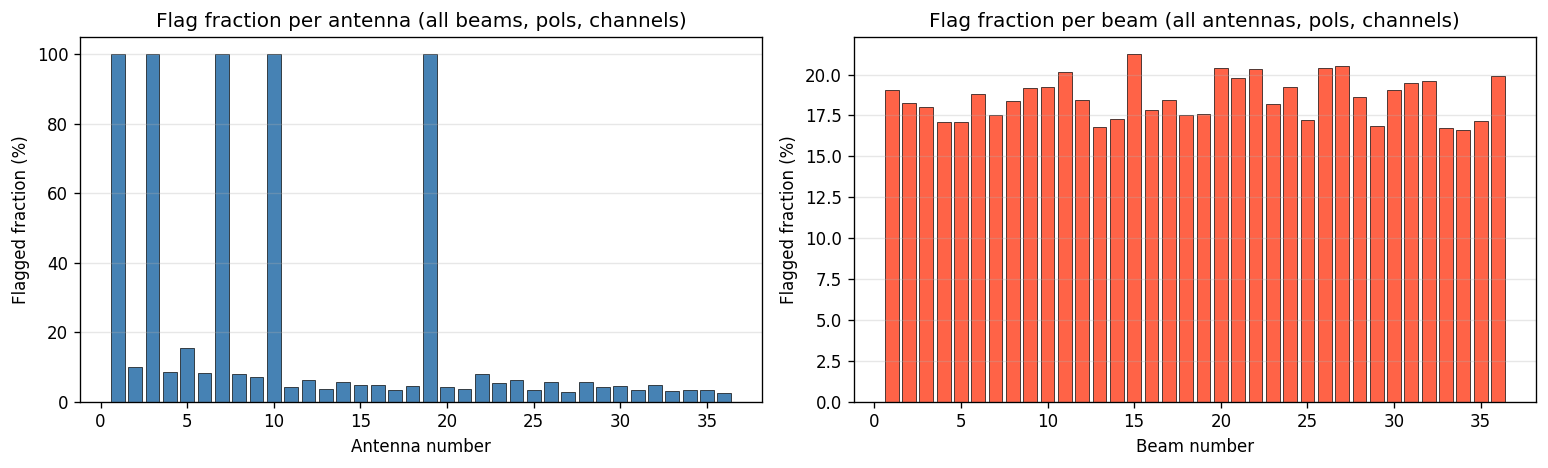

Overall flag fraction : 18.56%
Most flagged antenna  : 1  (100.0%)
Most flagged beam     : 15  (21.2%)


In [3]:
# flags shape: (ant, beam, pol, freq)  — no spatial axes
# Collapse over beam, pol, freq → per-antenna flagging fraction
flag_per_ant  = stokes_flags.mean(axis=(1, 2, 3))   # (N_ANT,)
flag_per_beam = stokes_flags.mean(axis=(0, 2, 3))   # (N_BEAM,)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(antennas, flag_per_ant * 100, color='steelblue', edgecolor='k', linewidth=0.4)
axes[0].set_xlabel('Antenna number')
axes[0].set_ylabel('Flagged fraction (%)')
axes[0].set_title('Flag fraction per antenna (all beams, pols, channels)')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(beams, flag_per_beam * 100, color='tomato', edgecolor='k', linewidth=0.4)
axes[1].set_xlabel('Beam number')
axes[1].set_ylabel('Flagged fraction (%)')
axes[1].set_title('Flag fraction per beam (all antennas, pols, channels)')
axes[1].grid(axis='y', alpha=0.3)

fig.tight_layout()
plt.show()

print(f"Overall flag fraction : {stokes_flags.mean()*100:.2f}%")
print(f"Most flagged antenna  : {antennas[np.argmax(flag_per_ant)]}  ({flag_per_ant.max()*100:.1f}%)")
print(f"Most flagged beam     : {beams[np.argmax(flag_per_beam)]}  ({flag_per_beam.max()*100:.1f}%)")

## 4. Global Statistics (Alive Check)

**Objective:** Verify that the Stokes-I data array is numerically healthy before investing time in detailed analysis. This cell pools *all* finite values across every antenna, beam, frequency channel, and spatial pixel into a single flat vector and computes scalar summary statistics.

> **Scope limitation:** this is a deliberate *alive check*, not a scientific analysis. By collapsing all array structure into one number, inter-antenna, inter-beam, and per-channel information is destroyed. The role of this cell is only to confirm the data is non-zero, non-NaN, and in a plausible range. Fine-grained analysis follows in Sections 5–15.
>
> | Question | Section addressing it |
> |---|---|
> | Are all antennas consistent in amplitude? | §7 — antenna×beam amplitude matrix |
> | Are all antennas consistent in beam shape? | §8 — per-antenna FWHM heatmap |
> | Is any channel bad for specific antennas? | §5, §11 — bandpass and CV plots |
> | Which channels are explicitly flagged? | §12 — channel flag map |

### Statistics reported

| Statistic | Purpose | Expected range (normalised Stokes I) |
|---|---|---|
| `min` | Confirms no large negative artefacts | ≥ 0 (power is non-negative; small negatives from noise calibration can occur) |
| `max` | Confirms the peak response is in a sensible range | ~1–2 (normalised; value depends on per-beam-peak normalisation convention) |
| `mean` | Should be much less than `max` — most pixels are off-peak sidelobes | 0.1–0.5 typical |
| `median` | Robust central tendency; below mean for a right-skewed distribution | < mean |
| `std` | Rough measure of dynamic range | Similar order of magnitude to mean |
| `p5` / `p95` / `p99` | Colour-scale reference for later `imshow` plots | Used internally for `vmin`/`vmax` |

**What to check:**
- `max` should be a positive finite number. `nan` or `inf` means the Section 2 load failed.
- `min` significantly below zero (< −0.1) indicates a calibration artefact or possibly the wrong file.
- If all statistics print as `nan`, the polarisation index lookup (`POL_IDX['I']`) is wrong — verify `pols_stokes` printed correctly in Section 2.


In [4]:
stokes_I = stokes_data[:, :, POL_IDX['I'], :, :, :]   # (ant, beam, freq, y, x)

flat = stokes_I[np.isfinite(stokes_I)].ravel()
stats = {
    'min':    float(flat.min()),
    'max':    float(flat.max()),
    'mean':   float(flat.mean()),
    'median': float(np.median(flat)),
    'std':    float(flat.std()),
    'p5':     float(np.percentile(flat,  5)),
    'p95':    float(np.percentile(flat, 95)),
    'p99':    float(np.percentile(flat, 99)),
}
print('Global Stokes-I statistics (all antennas, beams, channels, pixels):')
for k, v in stats.items():
    print(f'  {k:<8}: {v:.6g}')

Global Stokes-I statistics (all antennas, beams, channels, pixels):
  min     : 1.31982e-07
  max     : 6395.04
  mean    : 0.143067
  median  : 0.0124141
  std     : 3.35872
  p5      : 0.00174335
  p95     : 0.674921
  p99     : 1.71735


## 5. Cross-Channel Consistency per Antenna

**Objective:** Diagnose antenna-level bandpass anomalies and frequency channels that fail on specific antennas. This is the first two-dimensional view of the data, revealing structure that the global statistics of Section 4 cannot show.

### Computation

For each `(antenna, channel)` pair the code computes:
1. `nanmax` over the 15×15 spatial pixels — the peak beam response for that channel (applied per beam separately).
2. `nanmean` over the 36 beams — the beam-averaged peak response.

This collapses the `(ant, beam, freq, y, x)` array into a `(36, 288)` surface.

### Two-panel display

| Panel | x-axis | y-axis | Colour scale | Diagnostic |
|---|---|---|---|---|
| Top heatmap | Frequency (MHz) | Antenna index | Peak amplitude (robust 1–99th percentile) | Overall bandpass uniformity across antennas |
| Bottom line plot | Frequency (MHz) | Peak amplitude | One coloured line per antenna + thick black mean | Per-antenna spectral shape |

### Interpretation

- **All antennas track the same smooth bandpass** → the holography calibration is consistent across the array. Some variation near band edges (< 820 MHz, > 1070 MHz) is normal due to reduced sensitivity.
- **One antenna shows a step, notch, or flat spectrum** → possible correlator or LO issue for that antenna during the observation. Compare with its beam maps in Section 6 and spectra in Section 11.
- **A vertical stripe in the heatmap (one channel, all antennas)** → global RFI or globally flagged channel affecting the whole array. Will also appear in Sections 11 and 12.
- **A horizontal stripe (one antenna, all channels)** → that antenna has a systematic gain problem across the whole band. Likely also heavily flagged in Section 3.
- **Isolated hot or cold cells** → antenna-channel-specific RFI or calibration failures; worth flagging for follow-up.

**What to expect for SB82194 clean data:**
- A smooth, gradually falling bandpass from ~800 MHz to ~1087 MHz (ASKAP Band 2 sensitivity profile).
- Empty antenna rows (indices 0, 2, 6, 9, 18) will appear as flat zero/NaN stripes — this is expected.
- Coefficient of variation across antennas per channel < 10% for most of the band.


/var/folders/n9/bmgtwyfd1h314fqqyqwn522000j5dq/T/ipykernel_33109/3313811841.py:4: RuntimeWarning: All-NaN slice encountered
  np.nanmax(stokes_I, axis=(-2, -1)),   # max over y,x → (ant, beam, freq)
/var/folders/n9/bmgtwyfd1h314fqqyqwn522000j5dq/T/ipykernel_33109/3313811841.py:3: RuntimeWarning: Mean of empty slice
  peak_ant_chan = np.nanmean(


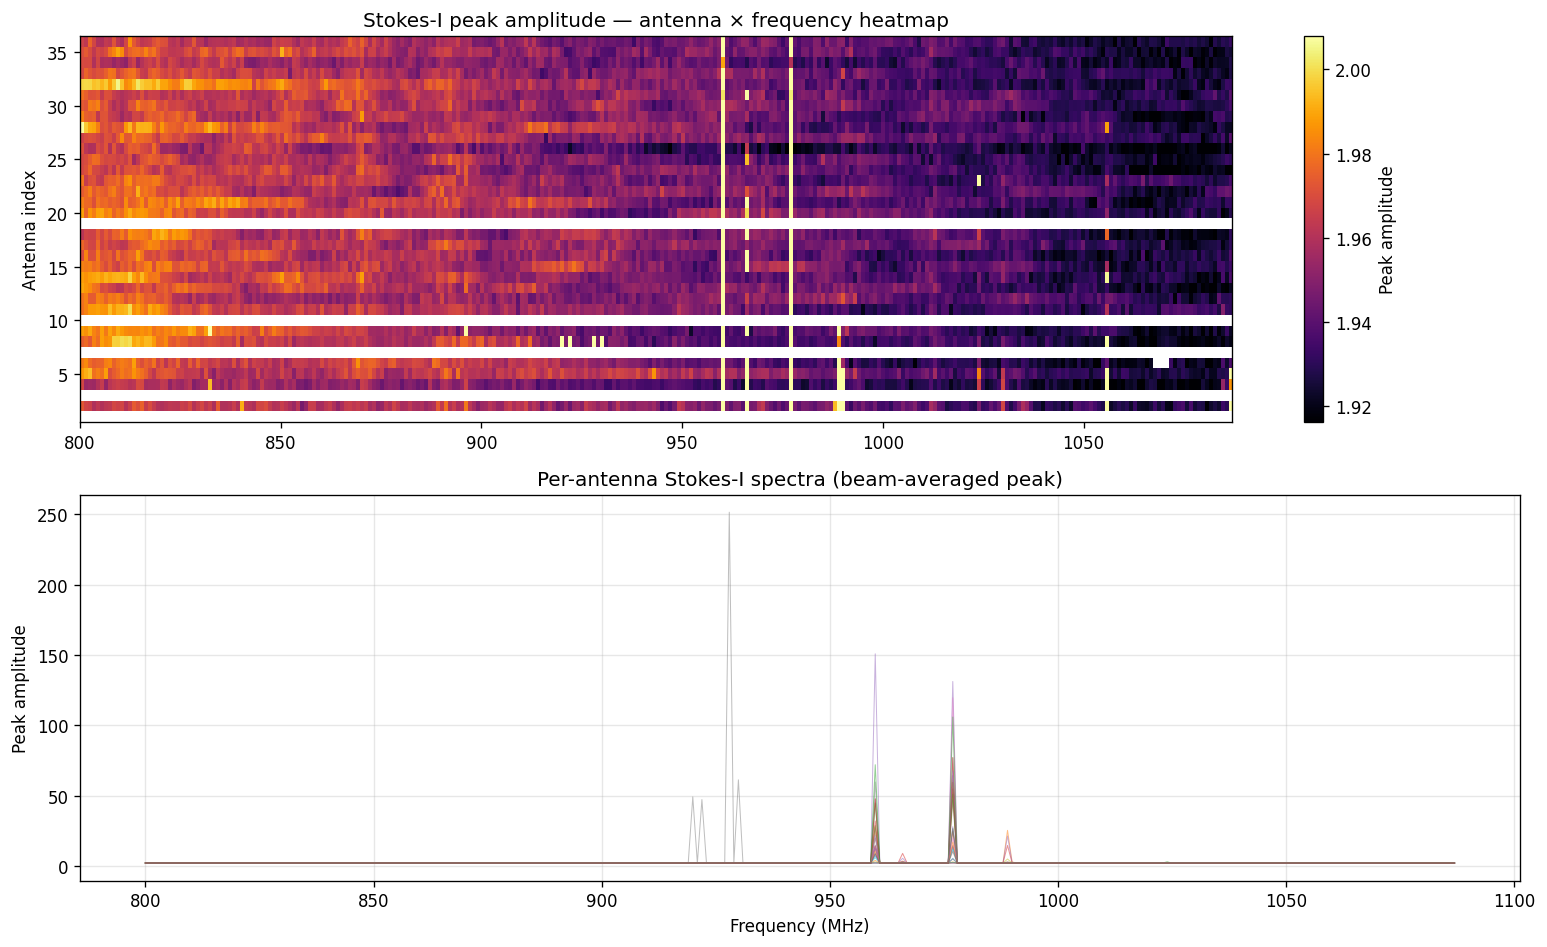

In [5]:
# peak amplitude per (antenna, channel): average over beams then max over spatial
# shape: (N_ANT, N_FREQ)
peak_ant_chan = np.nanmean(
    np.nanmax(stokes_I, axis=(-2, -1)),   # max over y,x → (ant, beam, freq)
    axis=1                                 # mean over beams → (ant, freq)
)

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# Heatmap: antenna vs frequency  — robust colour scale
_vmin, _vmax = np.nanpercentile(peak_ant_chan[np.isfinite(peak_ant_chan)], [1, 99])
im = axes[0].imshow(
    peak_ant_chan, aspect='auto', origin='lower',
    extent=[freqs_mhz[0], freqs_mhz[-1], 0.5, N_ANT + 0.5],
    cmap='inferno', vmin=_vmin, vmax=_vmax
)
axes[0].set_ylabel('Antenna index')
axes[0].set_title('Stokes-I peak amplitude — antenna × frequency heatmap')
plt.colorbar(im, ax=axes[0], label='Peak amplitude')

# Per-antenna spectra
for i in range(N_ANT):
    axes[1].plot(freqs_mhz, peak_ant_chan[i], lw=0.6, alpha=0.5, label=f'Ant {antennas[i]}')
axes[1].plot(freqs_mhz, peak_ant_chan.mean(axis=0), lw=1.8, color='k', label='Mean')
axes[1].set_xlabel('Frequency (MHz)')
axes[1].set_ylabel('Peak amplitude')
axes[1].set_title('Per-antenna Stokes-I spectra (beam-averaged peak)')
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()


## 6. Per-Antenna Beam Maps

**Objective:** Visually inspect the full 36-beam closepack footprint for a single antenna. Each panel shows the frequency-averaged Stokes-I power pattern on the 15×15 holography grid, self-normalised so that the peak value in each panel is 1. The 6×6 layout mirrors the closepack-36 beam grid used by ASKAP.

### How to use

Set `ANT_IDX` (0-based row index into the `antennas` array) to select which antenna to inspect. Repeat for multiple antennas to compare beam shapes across the array.

> **Valid antenna indices for SB82194:** all except 0, 2, 6, 9, 18 (which are absent from the observation and will produce blank mosaics).

### What each panel shows

- **Colour scale:** `inferno`, self-normalised per beam (peak = 1.0). The 99th percentile of finite values is used as `vmax` for robustness against isolated hot pixels.
- **Axes:** angular offsets in degrees from the phase centre (±4.2° in both axes for the full 15×15 grid).
- **Panel label:** beam number (1-based, matching the `beams` metadata array).

### What to look for

| Feature | Implication |
|---|---|
| Compact bright spot in each panel, similar position and size | Healthy antenna — all beams are well-formed and consistently placed |
| One or more entirely blank (black) panels | That beam is heavily flagged or was not scanned; cross-check Section 3 |
| Beam shape systematically elongated or off-centre compared to other antennas | Pointing or beam-steering issue; compare this antenna with others |
| Noisy / structured background (stripes, cross-patterns, ring artefacts) | Holography calibration residuals; indicates lower data quality for this antenna |
| One beam dramatically smaller or larger than its neighbours | Isolated beam anomaly; inspect in detail using Section 10 |

**What to check:**
- The bright spot (main lobe) should appear near the centre of each panel.
- All 36 beams should show similar shapes and peak intensities after self-normalisation.
- Run this cell for several different antennas and compare — beam shapes should be nearly identical across antennas for a well-calibrated holography observation. Variations between antennas indicate per-antenna calibration errors.


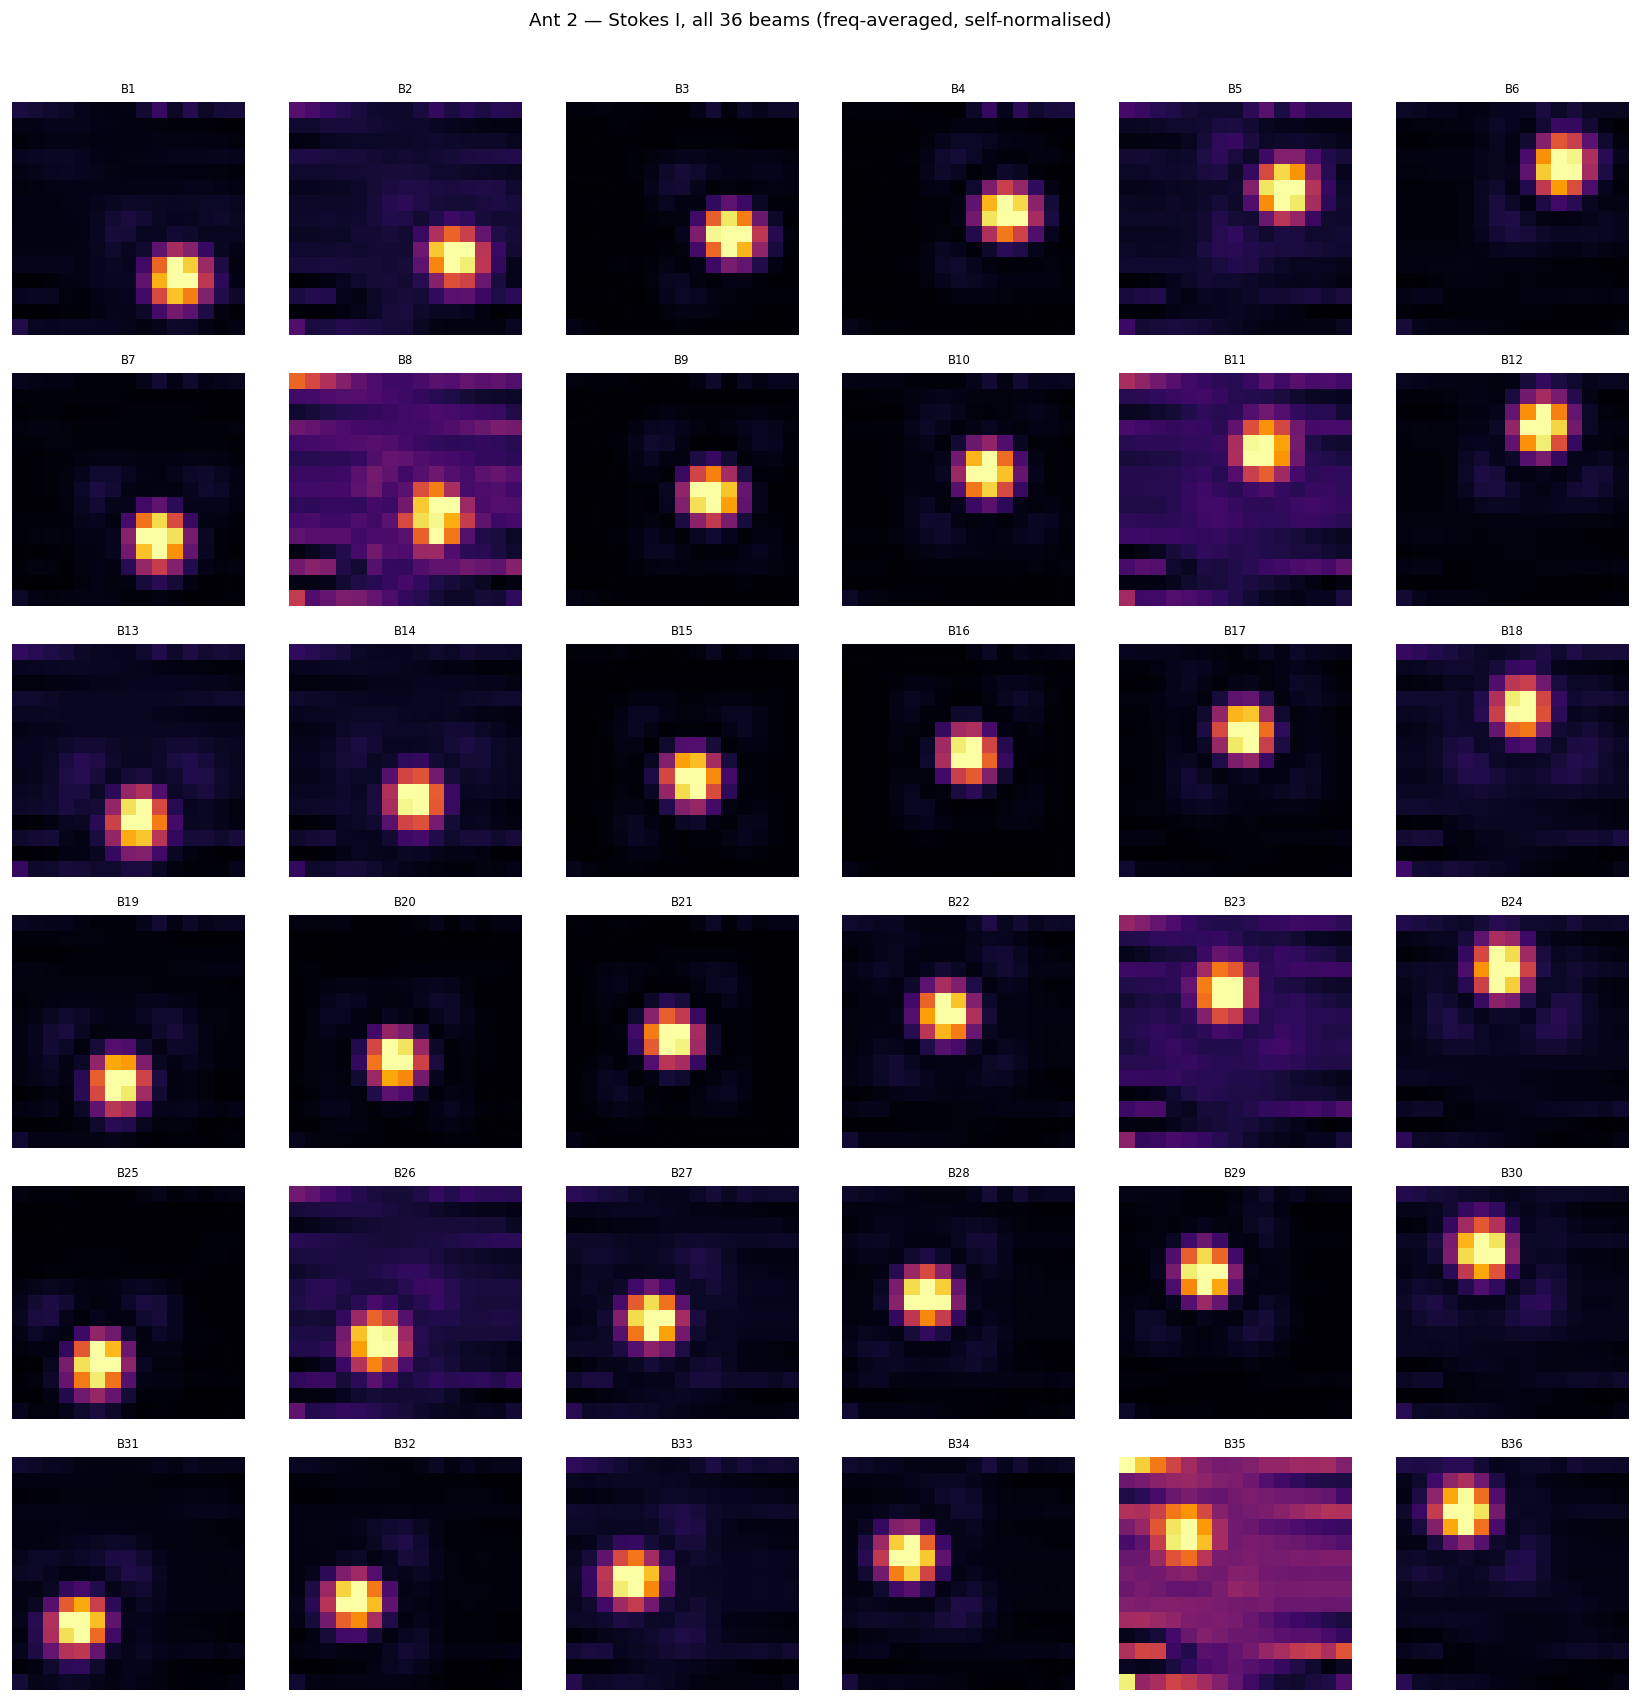

In [6]:
# NOTE: antenna indices 0,2,6,9,18 (ant numbers 1,3,7,10,19) are all-NaN in this dataset.
# Valid indices: all others (1,3,4,5,7,8,10..17,19..35)
ANT_IDX = 1   # ← change to inspect a different antenna (0-based, must be a valid index above)

# frequency-average over channels → (beam, y, x)
avg_maps = np.nanmean(stokes_data[ANT_IDX, :, POL_IDX['I'], :, :, :], axis=1)  # (36, 15, 15)

fig, axes = plt.subplots(6, 6, figsize=(14, 14))
axes = axes.ravel()

for b in range(N_BEAM):
    img = avg_maps[b]
    peak = np.nanmax(img)
    img_norm = img / peak if peak > 0 else img
    # robust vmax: 99th percentile of finite values
    _vmax_b = np.nanpercentile(img_norm[np.isfinite(img_norm)], 99) if np.any(np.isfinite(img_norm)) else 1.0
    axes[b].imshow(
        img_norm, origin='lower', cmap='inferno',
        extent=[x_axis_deg[0], x_axis_deg[-1], y_axis_deg[0], y_axis_deg[-1]],
        vmin=0, vmax=max(_vmax_b, 1e-6)
    )
    axes[b].set_title(f'B{beams[b]}', fontsize=7)
    axes[b].axis('off')

fig.suptitle(
    f'Ant {antennas[ANT_IDX]} — Stokes I, all 36 beams (freq-averaged, self-normalised)',
    fontsize=11, y=1.01
)
fig.tight_layout()

plt.show()

## 7. Antenna–Beam Amplitude Matrix

**Objective:** Provide a single compact diagnostic of the entire (antenna, beam) amplitude landscape. Each cell of this 36×36 heatmap answers: *how bright is this antenna's beam pattern at this beam position?* This is the primary screening tool for identifying antennas or beams with systematic gain anomalies.

### Computation

The matrix value for cell `(a, b)` is derived as follows:
1. **Frequency average:** `nanmean` over all 288 channels → frequency-averaged Stokes-I map of shape `(ant, beam, y, x)`.
2. **Spatial peak:** `nanmax` over the 15×15 pixels → the peak pixel value of the averaged map.

The result is a matrix that is independent of spatial position and frequency, giving a clean per-(antenna, beam) amplitude scalar.

**Colour scale:** robust 1–99th percentile of all finite cells. Absent-antenna rows (all-NaN) appear at the `vmin` colour.

**Outlier annotation:** cells more than 3σ from the global mean are highlighted with cyan rectangles — these are candidate anomalies requiring follow-up investigation.

### What to look for

| Pattern | Interpretation |
|---|---|
| Uniform colour across the whole matrix | Good — all antennas contribute equally to all beams |
| One row darker than all others | That antenna has a systematic gain reduction; inspect its spectrum in Section 11 and compare its beam maps in Section 6 |
| One column darker across all antennas | That beam is consistently weak for all antennas; possibly at the edge of the PAF footprint or a beam-former steering problem |
| Isolated cyan-boxed cells | Single (antenna, beam) failures — examine via difference maps in Section 13 |
| Blocks of NaN rows | Missing antennas (expected for indices 0, 2, 6, 9, 18 in SB82194) |
| Brightest cells clustered in specific beam columns | Normal for peripheral beams that may have different effective gain in the holography scan |

**What to check:**
- The printed `mean ± std` sets the reference for the typical peak amplitude for this SB. Compare across multiple SBs to track instrument stability over time.
- A small outlier count (< 5 cells) is acceptable. Many cyan boxes suggest a more systemic calibration failure.
- Cross-reference outlier cells with the FWHM matrix in Section 8: cells that are outliers in *both* amplitude and FWHM are the most concerning.


/var/folders/n9/bmgtwyfd1h314fqqyqwn522000j5dq/T/ipykernel_33109/1499406410.py:3: RuntimeWarning: Mean of empty slice
  np.nanmean(stokes_data[:, :, POL_IDX['I'], :, :, :], axis=2),   # mean freq → (ant,beam,y,x)
/var/folders/n9/bmgtwyfd1h314fqqyqwn522000j5dq/T/ipykernel_33109/1499406410.py:2: RuntimeWarning: All-NaN slice encountered
  peak_mat = np.nanmax(


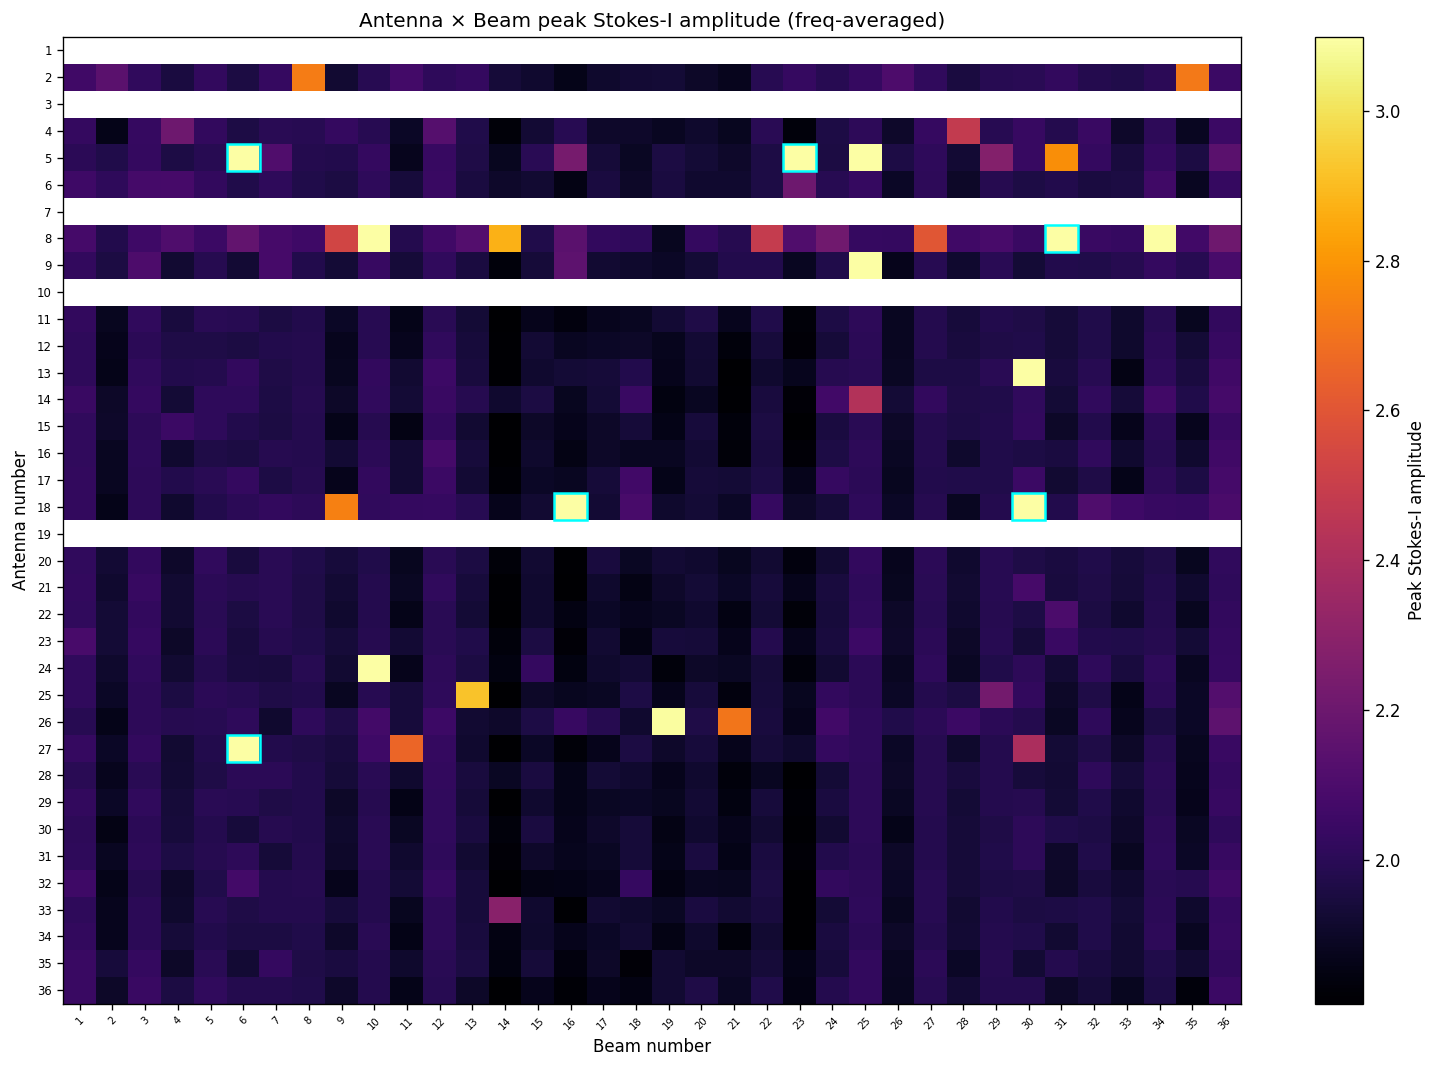

Mean peak amplitude : 2.0110  ±  0.7014
Outliers (>3σ)      : 6  cells circled in cyan


In [7]:
# peak over spatial, mean over frequency → (ant, beam)
peak_mat = np.nanmax(
    np.nanmean(stokes_data[:, :, POL_IDX['I'], :, :, :], axis=2),   # mean freq → (ant,beam,y,x)
    axis=(-2, -1)                                                      # max spatial → (ant,beam)
)

_vmin_pm, _vmax_pm = np.nanpercentile(peak_mat[np.isfinite(peak_mat)], [1, 99])

fig, ax = plt.subplots(figsize=(13, 9))
im = ax.imshow(peak_mat, aspect='auto', cmap='inferno', origin='upper',
               vmin=_vmin_pm, vmax=_vmax_pm)
plt.colorbar(im, ax=ax, label='Peak Stokes-I amplitude')
ax.set_xticks(np.arange(N_BEAM))
ax.set_xticklabels(beams, fontsize=6, rotation=45)
ax.set_yticks(np.arange(N_ANT))
ax.set_yticklabels(antennas, fontsize=7)
ax.set_xlabel('Beam number')
ax.set_ylabel('Antenna number')
ax.set_title('Antenna × Beam peak Stokes-I amplitude (freq-averaged)')

# annotate outliers (> 3σ from mean)
mu, sig = np.nanmean(peak_mat), np.nanstd(peak_mat)
outliers = np.argwhere(np.abs(peak_mat - mu) > 3 * sig)
for (i, j) in outliers:
    ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                               fill=False, edgecolor='cyan', lw=1.5))

fig.tight_layout()
plt.show()

print(f'Mean peak amplitude : {mu:.4f}  ±  {sig:.4f}')
print(f'Outliers (>3σ)      : {len(outliers)}  cells circled in cyan')


## 8. FWHM Estimation Across Antennas

**Objective:** Quantify the angular size of each beam pattern for every (antenna, beam) combination and identify antenna- or beam-level anomalies in beam width. A consistent FWHM across antennas confirms stable PAF beam formation; deviations indicate potential hardware or calibration issues.

### Method

FWHM is estimated using a half-power crossing algorithm (`fwhm_1d`):
1. Slice the frequency-averaged Stokes-I map through the centre row (x-profile) and centre column (y-profile).
2. Find all pixels where the profile ≥ half the peak value.
3. FWHM = angular distance between the first and last half-power crossing, read from the `x_axis_deg` / `y_axis_deg` calibration arrays.
4. Mean FWHM = `(FWHM_x + FWHM_y) / 2`, converted to arcminutes.

> **Limitation:** sampling only the cardinal-axis profiles averages out any beam ellipticity or position angle. For elliptical beam characterisation, a 2-D Gaussian fit (e.g. using `curve_fit`) would be more appropriate, but the 15×15 grid resolution makes reliable fitting marginal. The FITS 101×101 maps in `holopy_demo.ipynb` are better suited for Gaussian fitting.

### Two-panel display

| Panel | Content | What to check |
|---|---|---|
| Left heatmap | Mean FWHM (arcmin) for each (antenna, beam) | Look for rows or isolated cells significantly different from the median |
| Right box-plot | Distribution of FWHM across all valid antennas, per beam | Wide boxes or outlier points indicate high antenna-to-antenna scatter at that beam |

### Reading the box-plot (right panel)

Each vertical group corresponds to one beam and summarises the FWHM values across all valid (non-empty) antennas. The elements are:

| Element | Description |
|---|---|
| **Red/orange dash** | **Median** — 50th-percentile FWHM across antennas for that beam; the "typical" beam size at that position |
| **Blue rectangle** | **Interquartile range (IQR)** — spans the 25th to 75th percentile. A tall box means high antenna-to-antenna scatter; a short box means most antennas agree |
| **Whiskers** (vertical lines) | Extend to the most extreme point still within **1.5 × IQR** of the box edges. Asymmetry is normal; the distribution need not be symmetric around the median |
| **Circles** | **Outliers** — individual antennas whose FWHM falls beyond the whisker limits (> 1.5 × IQR from the box). Multiple circles for a single beam indicate that several antennas have anomalously large or small beam widths at that position |

**Practical reading:**
- Compact box + short whiskers + few circles → consistent, well-behaved beam across the array for that beam position.
- Tall box, long whiskers, or many outlier circles → antenna-dependent variation worth investigating further (e.g., per-antenna holography issues, RFI, or heavily flagged data in specific antennas).

### Expected values

For ASKAP Band 2 (~943 MHz) holography with the closepack-36 footprint:
- **Typical mean FWHM: ~55–90 arcmin**, varying by beam position within the footprint. Peripheral beams tend to be slightly larger than central beams.
- **Antenna-to-antenna std: < 5 arcmin** for a healthy observation.
- **Beam-to-beam spread (box-plot IQR) < 10 arcmin** is acceptable.

**What to check:**
- Antennas with FWHM > 10 arcmin above the median across many beams may have a pointing offset — cross-reference with centroid maps in Section 9.
- NaN cells in the heatmap indicate the beam had too low an SNR for a half-power crossing to be found (absent antennas or heavily flagged beams).
- The overall median and standard deviation printed below are useful reference values for comparing across SBs and monitoring instrument stability.


/var/folders/n9/bmgtwyfd1h314fqqyqwn522000j5dq/T/ipykernel_33109/2459585674.py:16: RuntimeWarning: Mean of empty slice
  avg_I = np.nanmean(stokes_data[:, :, POL_IDX['I'], :, :, :], axis=2)


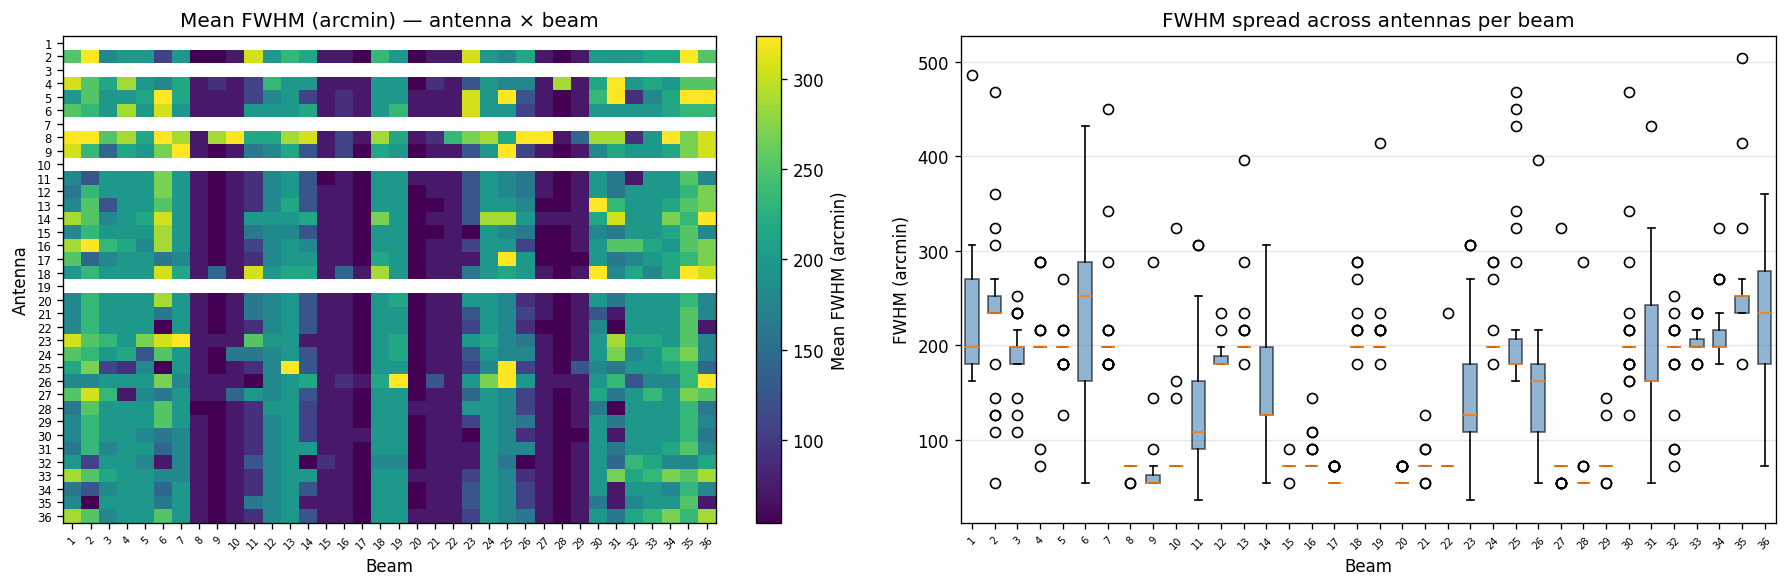

Overall median FWHM : 180.0 arcmin
Std across all cells: 81.37 arcmin


In [16]:
def fwhm_1d(profile, axis_deg):
    """Half-power FWHM in degrees for a 1-D profile."""
    if not np.any(np.isfinite(profile)):
        return np.nan
    peak = np.nanmax(profile)
    if peak <= 0:
        return np.nan
    half = peak / 2.0
    above = profile >= half
    if not above.any():
        return np.nan
    idxs = np.where(above)[0]
    return float(axis_deg[idxs[-1]] - axis_deg[idxs[0]])

# freq-averaged Stokes-I: (ant, beam, y, x)
avg_I = np.nanmean(stokes_data[:, :, POL_IDX['I'], :, :, :], axis=2)

fwhm_x = np.full((N_ANT, N_BEAM), np.nan)
fwhm_y = np.full((N_ANT, N_BEAM), np.nan)

for a in range(N_ANT):
    for b in range(N_BEAM):
        img = avg_I[a, b]
        cy, cx = img.shape[0]//2, img.shape[1]//2
        fwhm_x[a, b] = fwhm_1d(img[cy, :], x_axis_deg)
        fwhm_y[a, b] = fwhm_1d(img[:, cx], y_axis_deg)

fwhm_mean = (fwhm_x + fwhm_y) / 2.0
fwhm_arcmin = fwhm_mean * 60
_fv1, _fv99 = np.nanpercentile(fwhm_arcmin[np.isfinite(fwhm_arcmin)], [2, 98])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

im0 = axes[0].imshow(fwhm_arcmin, aspect='auto', cmap='viridis', origin='upper',
                     vmin=_fv1, vmax=_fv99)
plt.colorbar(im0, ax=axes[0], label='Mean FWHM (arcmin)')
axes[0].set_xticks(np.arange(N_BEAM))
axes[0].set_xticklabels(beams, fontsize=6, rotation=45)
axes[0].set_yticks(np.arange(N_ANT))
axes[0].set_yticklabels(antennas, fontsize=7)
axes[0].set_xlabel('Beam'); axes[0].set_ylabel('Antenna')
axes[0].set_title('Mean FWHM (arcmin) — antenna × beam')

# Box-plot: filter out all-NaN columns (empty antennas), per beam
axes[1].boxplot(
    [fwhm_arcmin[:, b][np.isfinite(fwhm_arcmin[:, b])] for b in range(N_BEAM)],
    positions=np.arange(N_BEAM),
    widths=0.6,
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6)
)
axes[1].set_xticks(np.arange(N_BEAM))
axes[1].set_xticklabels(beams, fontsize=6, rotation=45)
axes[1].set_xlabel('Beam')
axes[1].set_ylabel('FWHM (arcmin)')
axes[1].set_title('FWHM spread across antennas per beam')
axes[1].grid(axis='y', alpha=0.3)

fig.tight_layout()
plt.show()

print(f'Overall median FWHM : {np.nanmedian(fwhm_arcmin):.1f} arcmin')
print(f'Std across all cells: {np.nanstd(fwhm_arcmin):.2f} arcmin')


## 9. Centroid Offsets Across Antennas

**Objective:** Compare the measured intensity-weighted centroid position of each beam map across antennas, to identify per-antenna pointing anomalies. This section measures **relative** inter-antenna consistency, not absolute pointing accuracy.

---

### What does (0°, 0°) actually mean here?

The `x_axis_deg` / `y_axis_deg` axes in the HDF5 data represent angular offsets from the **phase centre of the holography raster scan** — i.e., the pointing centre of the telescope during the observation, not the nominal sky position of any individual beam.

ASKAP holography works as follows:

1. A single bright calibrator source is observed.
2. The telescope performs a **single raster scan** across the calibrator that is large enough for the calibrator to transit through the primary beam of every formed beam in the footprint. The raster scan does not target each beam individually.
3. All 36 formed beams record the calibrator signal simultaneously at each raster pointing. The holography software then extracts, for each beam, how much signal it received at each scan offset — assembling the 15×15 map stored in the HDF5.
4. The scan is **not done beam-by-beam**. The telescope does not re-centre the raster on each beam's intended sky position. A beam that is designed to point at (+0.8°, +0.5°) from boresight will see the calibrator cross its field at that offset during the raster, not at (0°, 0°).

**Consequence:** The peak of beam `b`'s response map will naturally sit near the beam's **designed footprint offset** from the raster phase centre, not at (0°, 0°). The displacement from (0°, 0°) therefore contains both:

- the **nominal beam pointing direction** (designed footprint geometry), which may be tens to ~100 arcmin for off-centre beams, and
- any **actual pointing residual** (what we care about for QA), which should be a few arcmin or less.

Without subtracting the nominal closepack-36 beam positions, the absolute displacement from (0,0) is **not a pointing-error diagnostic**. The nominal beam positions are available in the `holopy` footprint tables, but are not loaded here.

---

### How large is the closepack-36 footprint?

The closepack-36 footprint consists of 36 beams arranged in a hexagonal close-packing pattern, with neighbouring beam centres separated by a fixed pitch of **0.9°**. Together the 36 beams cover a combined field of view of approximately **30 square degrees**.

With 36 beams at 0.9° pitch in a hexagonal close-packing, the grid spans roughly 5–6 beam spacings across its widest axis. The outermost beam centres therefore sit approximately **2–3 × 0.9° ≈ 1.8°–2.7° from boresight**, depending on their position within the hex grid (corner vs. edge beams).

**Consequence for the centroid plots:** beams near the footprint edge will have centroids naturally displaced by 1°–2° (60–120 arcmin) from (0°, 0°), purely due to their designed pointing direction — not a fault. The displacement heatmap will therefore show large values for peripheral beams on all antennas; this is expected and does not indicate a problem.

> **How to verify from the actual data:** after running this cell, inspect `np.nanmax(np.abs(cx_deg))` and `np.nanmax(np.abs(cy_deg))` to see the actual outermost beam offsets measured for SB82194. The measured centroids averaged over all valid antennas (as done in the scatter plot) provide a data-driven map of the footprint geometry for this specific observation.

---

### What this section actually measures

Rather than absolute offsets, the diagnostics here exploit **inter-antenna consistency**:

> For a given beam `b`, all antennas that illuminate the same sky region should measure approximately the same centroid. If antenna `a` shows a centroid significantly displaced relative to the other antennas for that same beam, that is a per-antenna pointing anomaly.

The **displacement map** (left panel) should be read as: "how far is this antenna's centroid from (0,0)?" — which is dominated by the designed beam offset. All antennas should show a similar row-by-row pattern. Rows that break the pattern are anomalous.

The **scatter plot** (right panel) shows the mean centroid of each antenna averaged over all 36 beams. Because the footprint geometry is the same for all antennas, each antenna's mean over 36 beams should cluster near the same average footprint offset. An antenna sitting away from the cluster has a net pointing offset relative to the rest of the array.

---

### Method

For each `(antenna, beam)` pair, `scipy.ndimage.center_of_mass` computes the intensity-weighted mean pixel position of the frequency-averaged Stokes-I image. Negative and NaN pixel values are zeroed out (only positive emission contributes). The pixel coordinates are converted to degrees using the `x_axis_deg` / `y_axis_deg` arrays.

The **displacement magnitude** $d = \sqrt{\Delta x^2 + \Delta y^2}$ is computed in arcminutes for the heatmap.

---

### Interpretation

| Observation | Likely cause |
|---|---|
| All antennas cluster tightly in the scatter plot | Consistent pointing across the array — beam-former steering is stable |
| One antenna offset from the cluster | Per-antenna pointing error; that antenna's holography weights should be treated with caution |
| All antennas offset together in one direction | Global pointing bias; the raster scan phase centre may not coincide with the expected footprint centre |
| Large displacement for a specific beam only, consistent across all antennas | Designed offset for that beam is large (expected for peripheral beams in closepack-36), not a fault |
| Large displacement for a specific beam on one antenna only | Beam-former steering anomaly on that antenna for that beam |

**What to check:**
- Antennas absent (indices 0, 2, 6, 9, 18) produce NaN centroids and will not appear in the scatter plot — expected.
- The scatter plot cluster spread gives a practical estimate of array-wide centroid RMS. For a well-calibrated observation, the inter-antenna spread (after removing the common mean) should be < 3 arcmin.
- For **absolute** pointing-error estimates, the nominal closepack-36 beam positions must be subtracted from these centroids. That analysis is outside the scope of this QA notebook.


/var/folders/n9/bmgtwyfd1h314fqqyqwn522000j5dq/T/ipykernel_33109/3839434549.py:31: RuntimeWarning: Mean of empty slice
  mean_cx = np.nanmean(cx_deg, axis=1) * 60   # arcmin
/var/folders/n9/bmgtwyfd1h314fqqyqwn522000j5dq/T/ipykernel_33109/3839434549.py:32: RuntimeWarning: Mean of empty slice
  mean_cy = np.nanmean(cy_deg, axis=1) * 60


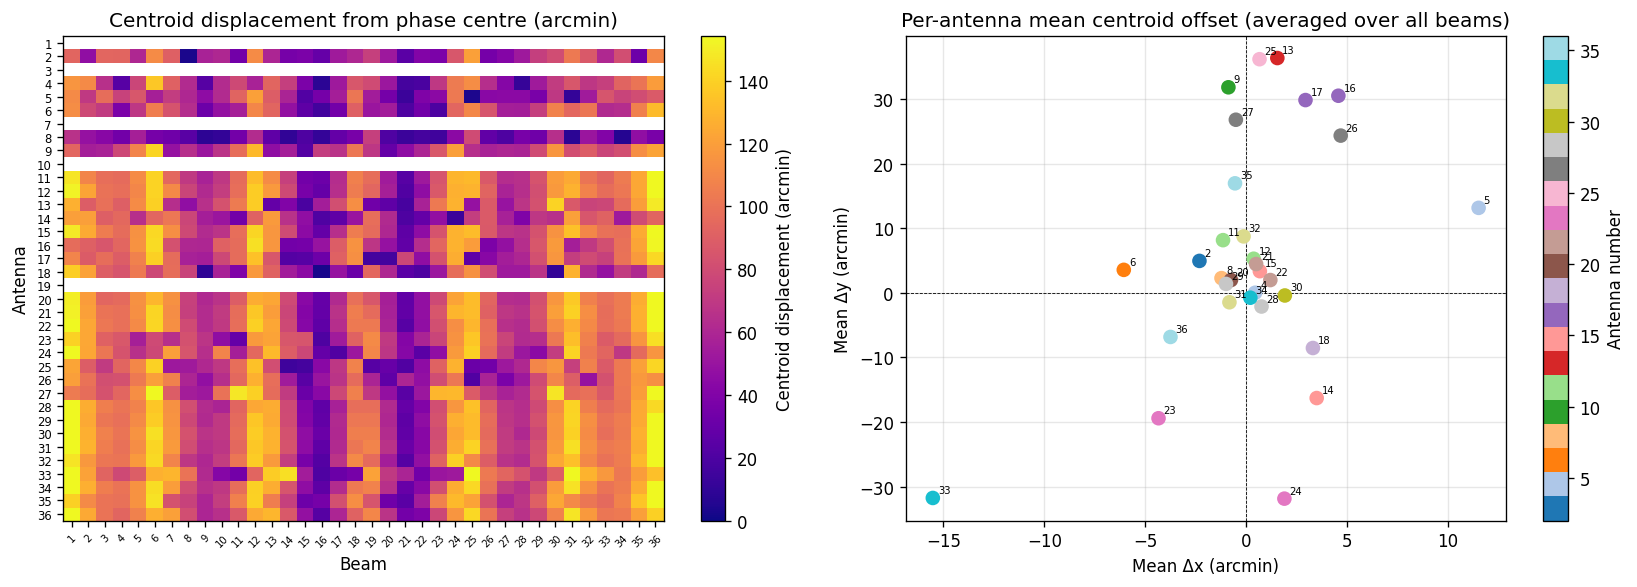

In [9]:
cx_deg = np.full((N_ANT, N_BEAM), np.nan)
cy_deg = np.full((N_ANT, N_BEAM), np.nan)

for a in range(N_ANT):
    for b in range(N_BEAM):
        img = avg_I[a, b]
        img_pos = np.where(img > 0, img, 0.0)
        total = img_pos.sum()
        if total > 0:
            yc, xc = center_of_mass(img_pos)
            cx_deg[a, b] = np.interp(xc, np.arange(NX), x_axis_deg)
            cy_deg[a, b] = np.interp(yc, np.arange(NY), y_axis_deg)

displace = np.sqrt(cx_deg**2 + cy_deg**2)  # (ant, beam) in degrees
disp_arcmin = displace * 60

_dv99 = np.nanpercentile(disp_arcmin[np.isfinite(disp_arcmin)], 98)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im1 = axes[0].imshow(disp_arcmin, aspect='auto', cmap='plasma', origin='upper',
                     vmin=0, vmax=_dv99)
plt.colorbar(im1, ax=axes[0], label='Centroid displacement (arcmin)')
axes[0].set_xticks(np.arange(N_BEAM))
axes[0].set_xticklabels(beams, fontsize=6, rotation=45)
axes[0].set_yticks(np.arange(N_ANT))
axes[0].set_yticklabels(antennas, fontsize=7)
axes[0].set_xlabel('Beam'); axes[0].set_ylabel('Antenna')
axes[0].set_title('Centroid displacement from phase centre (arcmin)')

mean_cx = np.nanmean(cx_deg, axis=1) * 60   # arcmin
mean_cy = np.nanmean(cy_deg, axis=1) * 60
sc = axes[1].scatter(mean_cx, mean_cy,
                     c=antennas, cmap='tab20', s=60, zorder=3)
plt.colorbar(sc, ax=axes[1], label='Antenna number')
for i, ant in enumerate(antennas):
    axes[1].annotate(str(ant), (mean_cx[i], mean_cy[i]), fontsize=6,
                     textcoords='offset points', xytext=(3, 3))
axes[1].axhline(0, color='k', lw=0.5, ls='--')
axes[1].axvline(0, color='k', lw=0.5, ls='--')
axes[1].set_xlabel('Mean Δx (arcmin)')
axes[1].set_ylabel('Mean Δy (arcmin)')
axes[1].set_title('Per-antenna mean centroid offset (averaged over all beams)')
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()


## 10. Stokes IQUV Panels per Antenna

**Objective:** Inspect the full polarimetric content of a single `(antenna, beam)` pair. The four Stokes parameters are shown side-by-side as frequency-averaged 2-D maps, enabling assessment of beam polarimetric leakage and calibration fidelity.

### Stokes parameter conventions

| Parameter | Physical meaning | Expected spatial structure | Colour map |
|---|---|---|---|
| **I** | Total intensity (beam power pattern) | Compact bright spot near phase centre; main lobe + sidelobe ring | `inferno` (0 → peak) |
| **Q** | Linear polarisation along the feed x/y axes | Anti-symmetric leakage pattern overlaid on the I main lobe | `RdBu_r` (symmetric about 0) |
| **U** | Linear polarisation at 45° to feeds | Similar anti-symmetric leakage, typically rotated ~45° relative to Q | `RdBu_r` |
| **V** | Circular polarisation | Should be near-zero for unpolarised or weakly polarised holography calibrators | `RdBu_r` |

### Colour scaling

- **Stokes I:** `[1st percentile, 99th percentile]` of finite pixel values — shows the full dynamic range of the main lobe and sidelobes.
- **Stokes Q, U, V:** symmetric `[−vlim, +vlim]` where `vlim` = 99th percentile of `|values|` — highlights even faint polarisation leakage without artefact saturation.

### How to use this cell

Change `ANT_IDX` and `BEAM_IDX` to navigate the full `(36, 36)` space:
- **Hold `BEAM_IDX` fixed, vary `ANT_IDX`:** compare how different antennas form the same beam — Q and U leakage patterns should be nearly identical between antennas for a stable, identical feed design.
- **Hold `ANT_IDX` fixed, vary `BEAM_IDX`:** see how the leakage pattern changes across the focal plane as beam position moves away from array boresight.

### What to check

- **Stokes I:** compact, smooth main lobe with a visible first sidelobe ring; no sharp stripes or bands.
- **Stokes Q and U peak leakage relative to I:** should be < 10% for ASKAP Band 2 holography. Values > 20% indicate a calibration or feed alignment issue.
- **Stokes V:** ideally < 2–3% of I at the beam peak. Non-zero V is a signature of differential ellipticity between the X and Y feeds on this antenna.
- **Asymmetric Q/U patterns between antennas:** may point to a polarisation angle rotation error specific to one antenna, or a feed rotation offset.


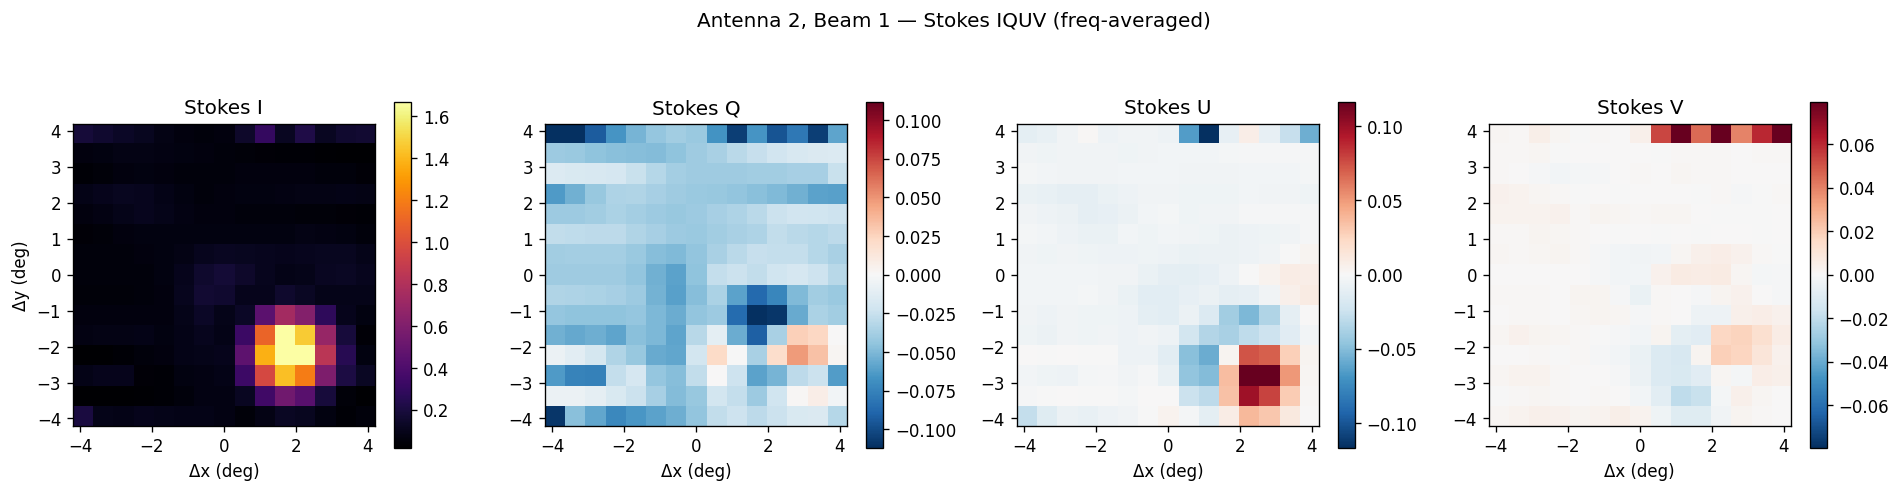

In [10]:
# NOTE: antenna indices 0,2,6,9,18 are all-NaN — use any other index
ANT_IDX  = 1   # ← 0-based; antenna number = antennas[ANT_IDX]
BEAM_IDX = 0   # ← 0-based; beam number   = beams[BEAM_IDX]

# freq-average: (pol, y, x)
stokes_maps = np.nanmean(stokes_data[ANT_IDX, BEAM_IDX, :, :, :, :], axis=1)   # (4, 15, 15)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
cmaps = ['inferno', 'RdBu_r', 'RdBu_r', 'RdBu_r']

for i, (stk, cmap) in enumerate(zip(pols_stokes, cmaps)):
    img = stokes_maps[i]
    finite = img[np.isfinite(img)]
    if stk == 'I':
        vmin = max(0, np.nanpercentile(finite, 1))
        vmax = np.nanpercentile(finite, 99)
    else:
        vlim = np.nanpercentile(np.abs(finite), 99)
        vmin, vmax = -vlim, vlim
    im = axes[i].imshow(
        img, origin='lower', cmap=cmap,
        extent=extent_deg, vmin=vmin, vmax=vmax
    )
    plt.colorbar(im, ax=axes[i], shrink=0.85)
    axes[i].set_title(f'Stokes {stk}')
    axes[i].set_xlabel('Δx (deg)')
    if i == 0:
        axes[i].set_ylabel('Δy (deg)')

fig.suptitle(
    f'Antenna {antennas[ANT_IDX]}, Beam {beams[BEAM_IDX]} — Stokes IQUV (freq-averaged)',
    y=1.01
)
fig.tight_layout()
plt.show()


## 11. Frequency Spectra per Antenna

**Objective:** Examine how each antenna's beam response varies with frequency for a chosen beam, and identify channels where antennas are internally inconsistent. This is the per-antenna analogue of the cross-beam channel consistency check in Section 5, but now the scatter is *across antennas* rather than across beams.

### Computation

For the selected `BEAM_IDX`, the peak Stokes-I amplitude over the 15×15 spatial grid is extracted for every `(antenna, frequency)` pair, giving a `(36, 288)` spectrum matrix. From this:

| Derived quantity | Formula | Shape | Purpose |
|---|---|---|---|
| `chan_mean` | `nanmean` over antennas | `(288,)` | Mean bandpass shape across the array for this beam |
| `chan_std` | `nanstd` over antennas | `(288,)` | Spread of antenna responses at each channel |
| `chan_cv` | `100 × std / mean` | `(288,)` | **Coefficient of variation (%)** — scale-independent measure of inter-antenna disagreement at each channel |

### Two-panel display

| Panel | Content |
|---|---|
| Top | Individual antenna spectra (thin coloured lines) + thick black array mean. Diverging antennas immediately stand out as lines lifting away from the pack. |
| Bottom | CV (%) per channel. A 5% threshold (dashed grey) separates routine variation from genuine channel anomalies. |

### Interpretation

- **Low, flat CV (< 5%):** all antennas agree well at every channel — holography calibration is consistent.
- **CV spikes at specific channels:** direction-dependent RFI affecting some antennas more than others, or per-antenna calibration failures at those channels. Cross-reference with the explicit flag map in Section 12.
- **One antenna line consistently above or below all others:** that antenna has a different effective gain across the full band — possibly a receiver problem or a mismatch in the holography-derived beam model.
- **Band edges (< 820 MHz, > 1070 MHz):** higher CV is normal here due to reduced ASKAP Band 2 sensitivity and lower holography SNR.

**What to check:**
- Median CV across the band should be < 5% for a healthy observation.
- Any channel with CV > 20% while its neighbours are clean warrants direct inspection of the raw flags (Section 12).
- Repeat for different `BEAM_IDX` values — beams at the edge of the footprint may show higher CV than central beams due to lower holography signal-to-noise.


/var/folders/n9/bmgtwyfd1h314fqqyqwn522000j5dq/T/ipykernel_33109/447313836.py:4: RuntimeWarning: All-NaN slice encountered
  spec = np.nanmax(


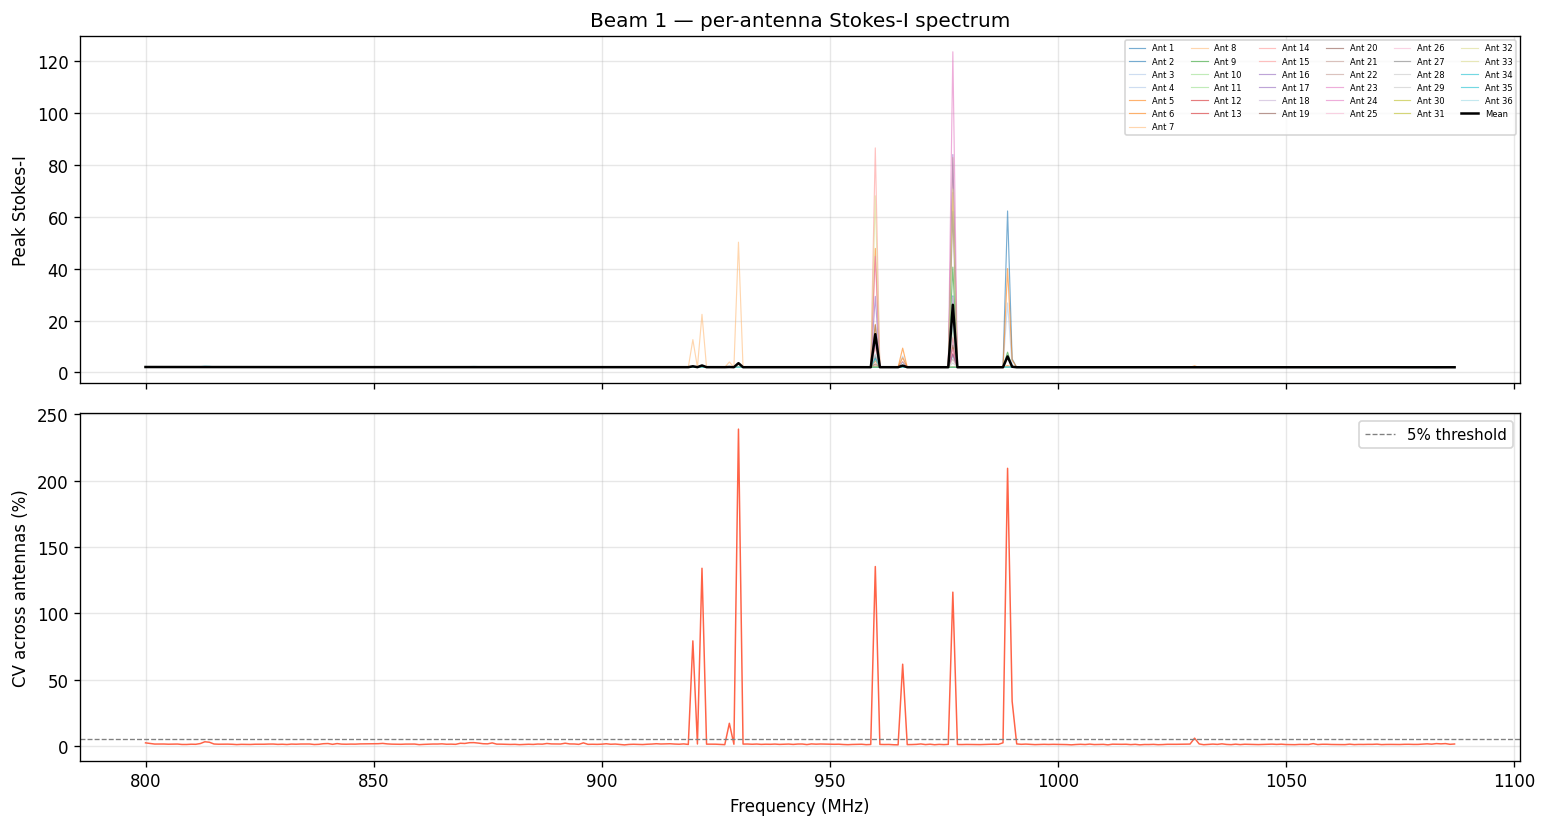

Median CV : 1.34%
Max CV    : 238.87% at 930.0 MHz


In [11]:
BEAM_IDX = 0   # ← beam to inspect

# peak over spatial, per (ant, freq): shape (N_ANT, N_FREQ)
spec = np.nanmax(
    stokes_data[:, BEAM_IDX, POL_IDX['I'], :, :, :],
    axis=(-2, -1)
)  # (N_ANT, N_FREQ)

chan_mean = np.nanmean(spec, axis=0)
chan_std  = np.nanstd(spec,  axis=0)
chan_cv   = 100.0 * chan_std / np.where(chan_mean > 0, chan_mean, np.nan)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

cmap_lines = plt.get_cmap('tab20')
for i in range(N_ANT):
    axes[0].plot(freqs_mhz, spec[i], lw=0.7, alpha=0.6,
                 color=cmap_lines(i / N_ANT), label=f'Ant {antennas[i]}')
axes[0].plot(freqs_mhz, chan_mean, 'k-', lw=1.5, label='Mean')
axes[0].set_ylabel('Peak Stokes-I')
axes[0].set_title(f'Beam {beams[BEAM_IDX]} — per-antenna Stokes-I spectrum')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=5, ncol=6, loc='upper right')

axes[1].plot(freqs_mhz, chan_cv, lw=0.9, color='tomato')
axes[1].axhline(5, ls='--', color='grey', lw=0.8, label='5% threshold')
axes[1].set_ylabel('CV across antennas (%)')
axes[1].set_xlabel('Frequency (MHz)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

print(f'Median CV : {np.nanmedian(chan_cv):.2f}%')
print(f'Max CV    : {np.nanmax(chan_cv):.2f}% at {freqs_mhz[np.nanargmax(chan_cv)]:.1f} MHz')

## 12. Channel Flagging per Antenna

**Objective:** Provide a direct view of the explicit `flags` boolean mask at per-(antenna, channel) resolution for a chosen beam. This complements the aggregate statistics of Section 3 by revealing *which specific channels* are bad on *which specific antennas*, enabling targeted quality assessment before science use.

### Computation

The `flags` dataset has shape `(ant, beam, pol, freq)`. For the selected `BEAM_IDX`, collapsing across polarisations with `any(axis)` produces a boolean image of shape `(N_ANT, N_FREQ)`: an entry is `True` if that channel is flagged for that antenna in *any* polarisation.

### Display

A 2-D heatmap with:
- **y-axis:** antenna number (1-based, ordered by antenna index, top to bottom)
- **x-axis:** frequency (MHz)
- **Colour:** white = unflagged, red = flagged (`Reds` colormap)

### Interpretation

| Pattern in the flag map | Likely cause |
|---|---|
| Vertical red bands (all antennas flagged at the same channel range) | Persistent broadband RFI affecting all antennas (e.g. satellite downlink, mobile phone band, GPS) |
| Horizontal red bands (one antenna flagged across all channels) | That antenna's correlator output failed for this SB; cross-check Sections 3, 5, and 11 |
| Scattered isolated red pixels | Intermittent RFI or edge-effect flags from the pipeline's auto-flagging thresholds |
| No red at all | Very clean observation with minimal RFI |
| All pixels red for empty-antenna rows | Expected — absent antennas (indices 0, 2, 6, 9, 18) are fully flagged by the pipeline |

**What to check:**
- The printed count of channels flagged for ≥1 antenna gives the fraction of the band affected by *any* RFI at this beam position.
- If > 20 channels are affected (> 7% of the 288-channel band), identify which frequency ranges to avoid when using this data.
- Compare with the CV plot in Section 11: channels with high CV should correspond to flagged channels here. If CV is high but no flags are set, the pipeline's auto-flagger may have missed some bad data.
- Repeat for different `BEAM_IDX` values — RFI can be highly direction-dependent and may affect specific beam directions more severely.


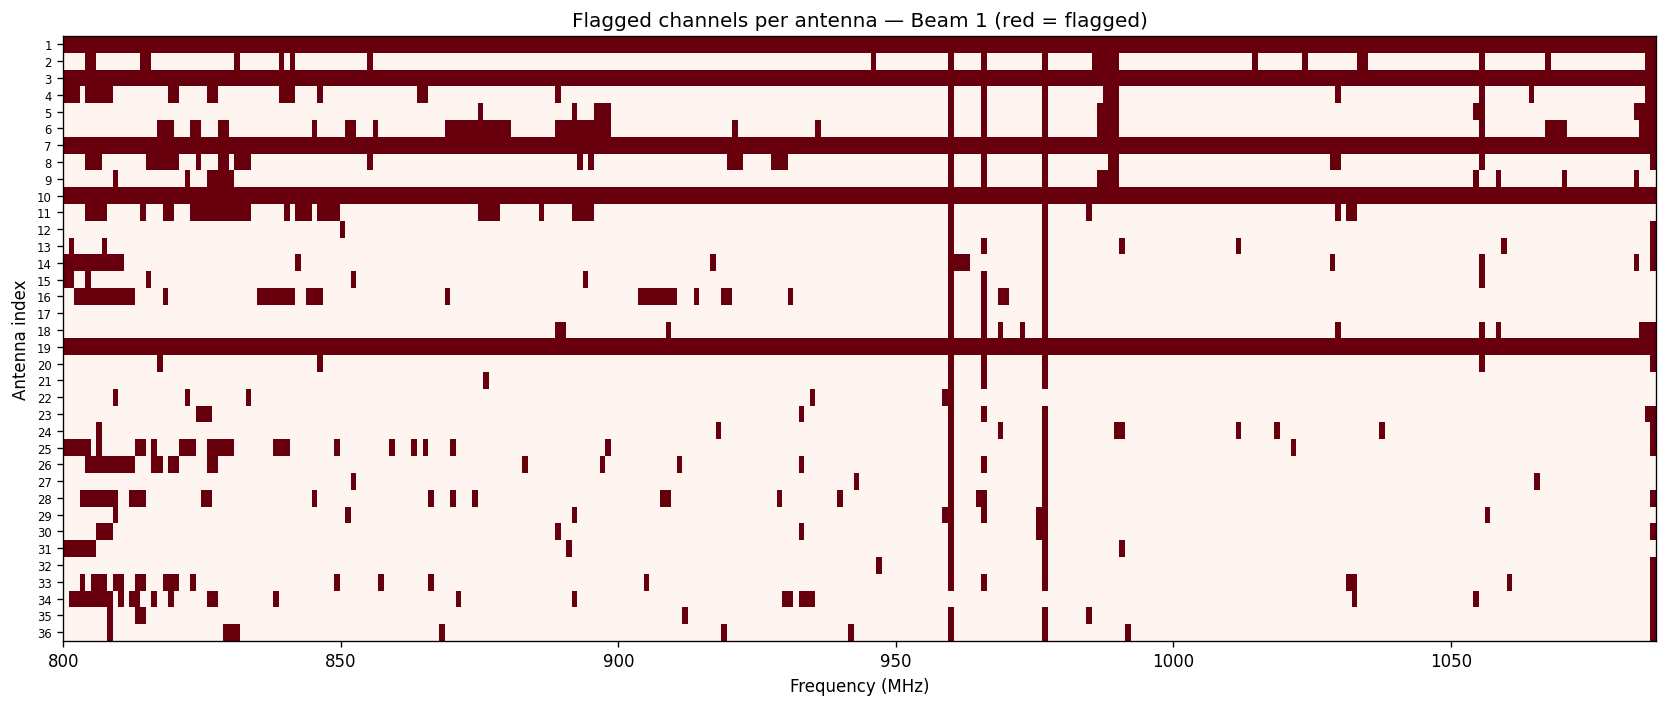

Channels flagged for ≥1 antenna : 288 / 288


In [12]:
BEAM_IDX = 0

# flags shape: (ant, beam, pol, freq)
# Any-pol flagging per (ant, freq)
flag_slice = stokes_flags[:, BEAM_IDX, :, :].any(axis=1)   # (N_ANT, N_FREQ)

fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(
    flag_slice.astype(float), aspect='auto', cmap='Reds',
    origin='upper',
    extent=[freqs_mhz[0], freqs_mhz[-1], N_ANT + 0.5, 0.5]
)
ax.set_xlabel('Frequency (MHz)')
ax.set_ylabel('Antenna index')
ax.set_yticks(np.arange(1, N_ANT + 1))
ax.set_yticklabels(antennas, fontsize=7)
ax.set_title(f'Flagged channels per antenna — Beam {beams[BEAM_IDX]} (red = flagged)')
fig.tight_layout()
plt.show()

flagged_chans = flag_slice.any(axis=0).sum()
print(f'Channels flagged for ≥1 antenna : {flagged_chans} / {N_FREQ}')

## 13. Antenna-to-Antenna Difference Maps

**Objective:** Directly quantify how much each antenna's beam pattern deviates from a chosen reference, pixel by pixel. This subtracts the common signal (average beam shape), leaving only the per-antenna variation and making subtle antenna-level differences immediately visible.

### Method

For each comparison antenna `a` and reference `REF_ANT`, the fractional difference at each pixel is:

$$\Delta(a) = \frac{B_a - B_{\text{ref}}}{B_{\text{ref}}} \times 100\%$$

where $B_a$ and $B_{\text{ref}}$ are the frequency-averaged Stokes-I maps (shape `15×15`) for the chosen beam. Pixels where $B_{\text{ref}} \leq 0$ are masked as undefined.

**Colour scale:** symmetric `RdBu_r` centred on 0%, clipped at ±(98th percentile of `|Δ|`) for robust display without artefact saturation. Red = comparison antenna brighter; blue = comparison antenna dimmer.

### How to use this cell

- Change `REF_ANT` to select the reference antenna index. Choosing a known-good antenna (e.g. index 1 = Ant 2) is recommended.
- Change `BEAM_IDX` to examine different beam positions.
- The cell shows the first 8 non-reference antennas by default. Increase the `[:8]` slice limit to see all 31 valid antennas.

### What to look for

| Difference map pattern | Interpretation |
|---|---|
| Near-zero everywhere (white/pale map) | This antenna's beam is nearly identical to the reference — excellent |
| Smooth low-amplitude gradient across the main lobe | Small pointing offset between the two antennas; difference looks like the spatial derivative of the beam pattern |
| Ring pattern matching the first sidelobe | Different sidelobe levels — gain or feed mismatch between the two antennas |
| Stripes or bands | Spectral calibration residuals that survive the frequency average |
| Large red/blue blobs covering the main lobe | Significant amplitude difference — one antenna is systematically brighter/dimmer |

**What to check:**
- Fractional differences < ±5% at the beam peak are generally acceptable for holography beam models.
- Systematic offsets > ±10% across the main lobe for many antennas relative to the *same* reference suggests the reference antenna itself may be anomalous — try a different reference.
- Beams at the edge of the footprint naturally show larger differences than central beams due to lower holography SNR.
- Cross-reference large-difference antennas with the outlier ranking in Section 14.


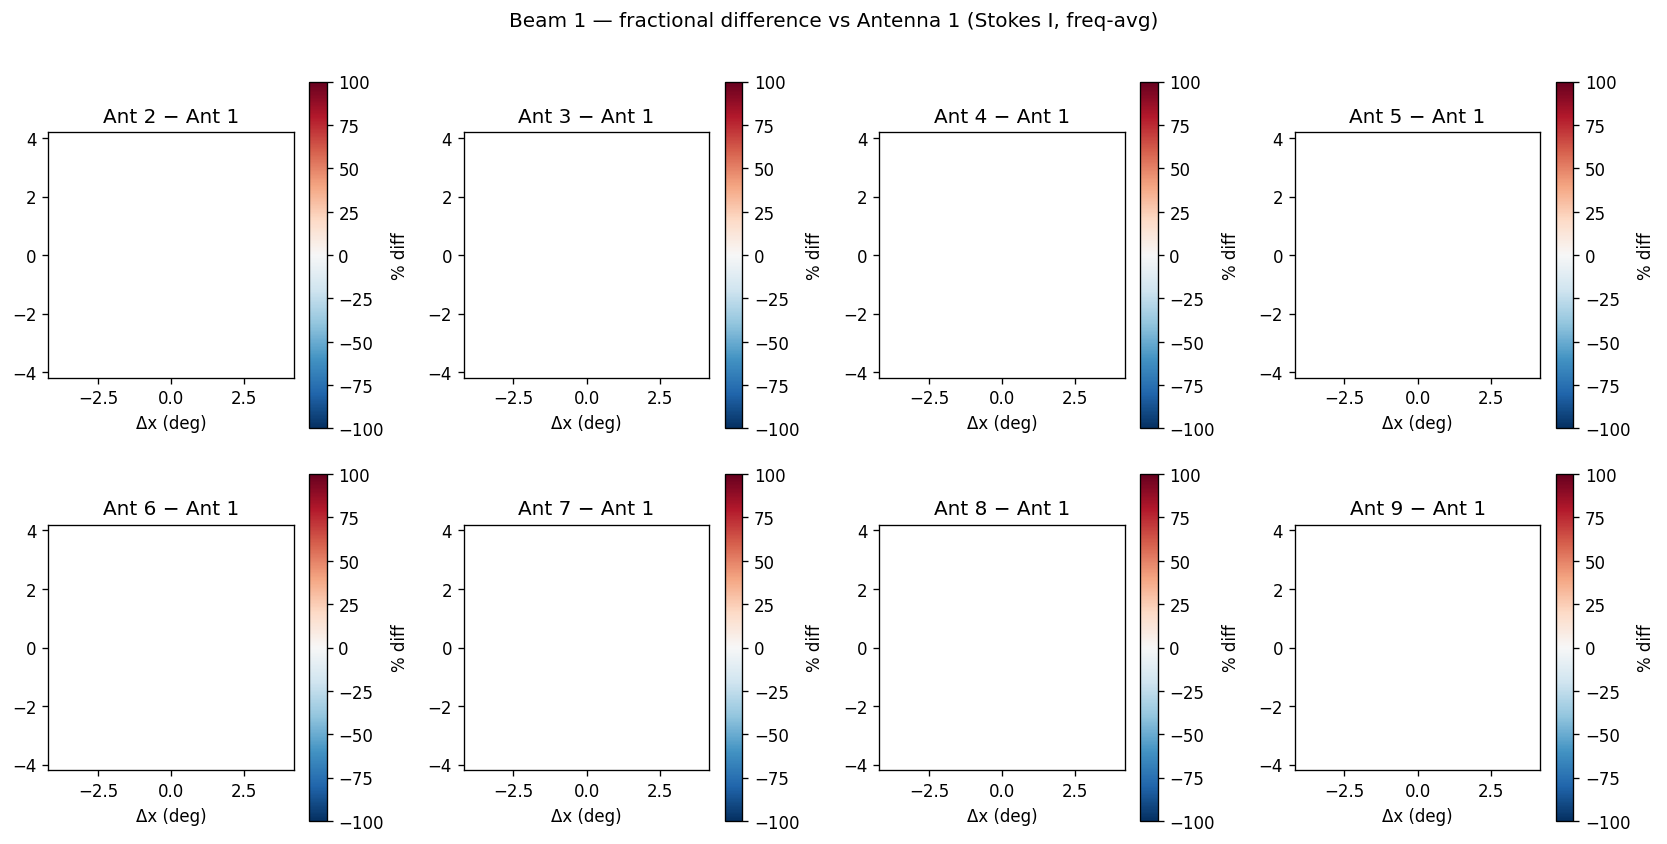

In [13]:
REF_ANT  = 0   # reference antenna index (0-based)
BEAM_IDX = 0

ref_map = avg_I[REF_ANT, BEAM_IDX]   # (y, x)

# show first 8 non-reference antennas for brevity
compare_ants = [a for a in range(N_ANT) if a != REF_ANT][:8]
ncols = 4
nrows = int(np.ceil(len(compare_ants) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.5))
axes = axes.ravel()

for idx, a in enumerate(compare_ants):
    diff = (avg_I[a, BEAM_IDX] - ref_map) / np.where(ref_map > 0, ref_map, np.nan)
    finite_diff = diff[np.isfinite(diff)]
    vmax = np.nanpercentile(np.abs(finite_diff), 98) if finite_diff.size else 1.0
    im = axes[idx].imshow(
        diff * 100, origin='lower', cmap='RdBu_r',
        extent=extent_deg, vmin=-vmax*100, vmax=vmax*100
    )
    plt.colorbar(im, ax=axes[idx], label='% diff')
    axes[idx].set_title(f'Ant {antennas[a]} − Ant {antennas[REF_ANT]}')
    axes[idx].set_xlabel('Δx (deg)')

for idx in range(len(compare_ants), len(axes)):
    axes[idx].axis('off')

fig.suptitle(
    f'Beam {beams[BEAM_IDX]} — fractional difference vs Antenna {antennas[REF_ANT]} (Stokes I, freq-avg)',
    y=1.01
)
fig.tight_layout()
plt.show()


## 14. Cross-Antenna Outlier Detection

**Objective:** Systematically identify antennas with anomalous beam amplitudes using a statistical criterion applied uniformly across all 36 beams. This provides a concise, reproducible summary of problematic antennas that is complementary to the visual diagnostics of Sections 6–13.

### Method

For each beam `b`, the distribution of peak Stokes-I amplitudes across the valid antennas is characterised by its inter-quartile range (IQR = Q3 − Q1). Antennas are labelled **outliers** for that beam if their amplitude falls outside the fence:

$$\text{fence} = [Q_1 - 2 \times \text{IQR},\; Q_3 + 2 \times \text{IQR}]$$

Using 2×IQR (rather than the standard 1.5×IQR Tukey fence) reduces false positives for a dataset where some antenna-to-antenna variation is expected near band edges. The result for each antenna is an integer **outlier beam count** — the number of beams for which it falls outside the fence across the full 36-beam footprint.

### Two-panel display

| Panel | Content | Interpretation |
|---|---|---|
| Left box-plot | Distribution of peak amplitudes across antennas, per beam | Wide boxes or visible outlier fliers (red circles) flag beams with high inter-antenna scatter |
| Right bar chart (ranked) | Antennas ranked by outlier beam count, red if ≥1 | Antennas with tall bars are deviant across the most beam positions |

### Interpretation

- **Most antennas have zero outlier beams:** the array is homogeneous in gain — good.
- **One antenna has a high outlier count (many beams flagged):** that antenna has a systematic gain difference relative to the array median; could indicate a receiver setting issue or bad gain calibration.
- **Many antennas show outlier behaviour *at the same beam*:** that beam's amplitude distribution is bimodal or multi-modal — suggests a beam-forming problem at that sky position affecting a subset of antennas.

**What to check:**
Cross-reference the top outlier antennas with:
- **Section 3** (flag fraction) — are they also the most flagged antennas?
- **Section 5** (bandpass heatmap) — do their spectra deviate from the array mean?
- **Section 7** (amplitude matrix) — do they show anomalous rows in the heatmap?

An antenna appearing as anomalous in all three diagnostics is a confirmed problem case that should be excluded from any subsequent beam model construction.


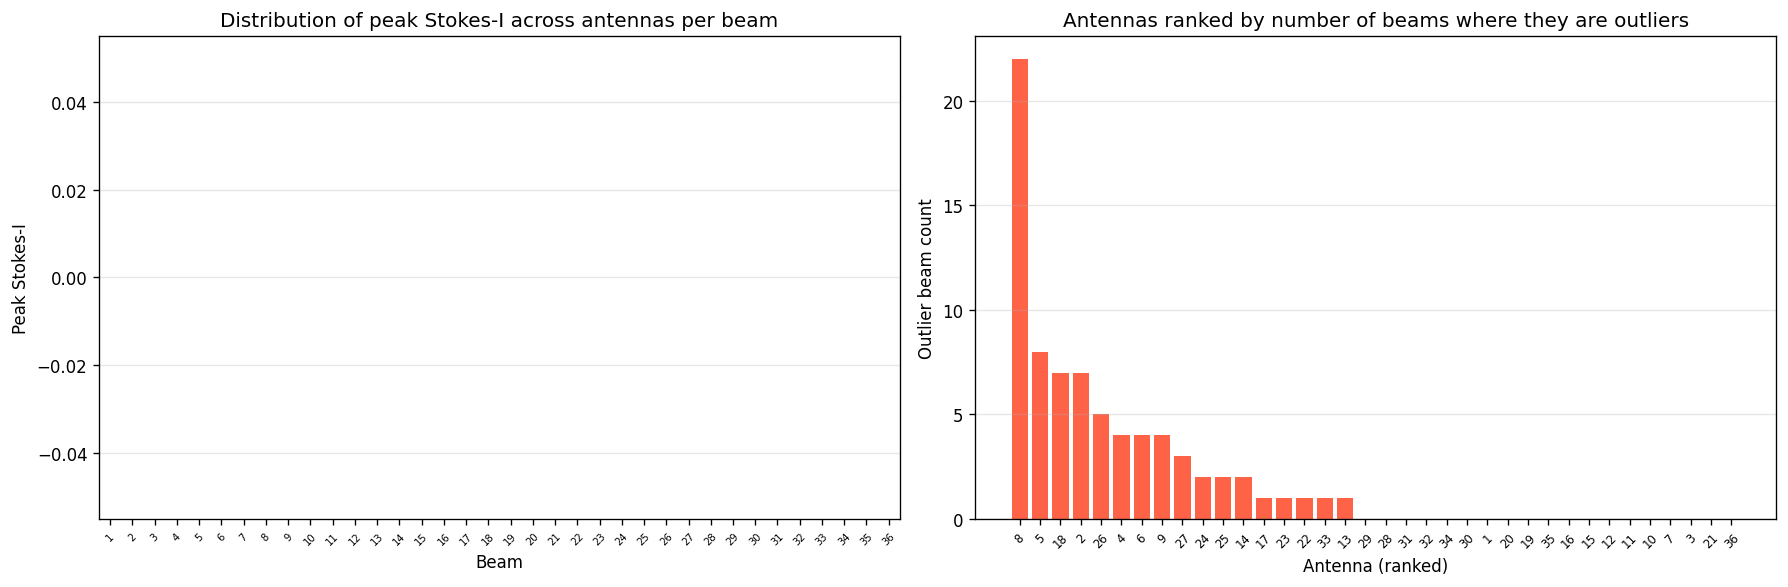

Top outlier antennas:
  Antenna   8  —  22 beam(s) outlier
  Antenna   5  —  8 beam(s) outlier
  Antenna  18  —  7 beam(s) outlier
  Antenna   2  —  7 beam(s) outlier
  Antenna  26  —  5 beam(s) outlier


In [14]:
# peak_mat shape: (N_ANT, N_BEAM)  — computed in Section 7

outlier_count = np.zeros(N_ANT, dtype=int)
for b in range(N_BEAM):
    col = peak_mat[:, b]
    q1, q3 = np.nanpercentile(col, 25), np.nanpercentile(col, 75)
    iqr = q3 - q1
    outlier_count += (col < q1 - 2*iqr) | (col > q3 + 2*iqr)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Box-plot
bp = axes[0].boxplot(
    [peak_mat[:, b] for b in range(N_BEAM)],
    positions=np.arange(N_BEAM),
    widths=0.6,
    patch_artist=True,
    flierprops=dict(marker='o', markersize=4, color='tomato'),
    boxprops=dict(facecolor='steelblue', alpha=0.5)
)
axes[0].set_xticks(np.arange(N_BEAM))
axes[0].set_xticklabels(beams, fontsize=6, rotation=45)
axes[0].set_xlabel('Beam')
axes[0].set_ylabel('Peak Stokes-I')
axes[0].set_title('Distribution of peak Stokes-I across antennas per beam')
axes[0].grid(axis='y', alpha=0.3)

# Ranks
sort_idx = np.argsort(-outlier_count)
axes[1].bar(np.arange(N_ANT), outlier_count[sort_idx],
            color=['tomato' if outlier_count[i] > 0 else 'steelblue' for i in sort_idx])
axes[1].set_xticks(np.arange(N_ANT))
axes[1].set_xticklabels(antennas[sort_idx], fontsize=7, rotation=45)
axes[1].set_xlabel('Antenna (ranked)')
axes[1].set_ylabel('Outlier beam count')
axes[1].set_title('Antennas ranked by number of beams where they are outliers')
axes[1].grid(axis='y', alpha=0.3)

fig.tight_layout()
plt.show()

print('Top outlier antennas:')
for i in sort_idx[:5]:
    print(f'  Antenna {antennas[i]:3d}  —  {outlier_count[i]} beam(s) outlier')

## 15. Raw XX/YY — Amplitude and Phase Inspection

**Objective:** Inspect the raw complex cross-correlation data *before* Stokes conversion, as stored in the XXYY HDF5 file. This provides the ground-truth view of the holography measurement at the individual feed-polarisation level, enabling diagnosis of feed imbalances, phase instabilities, and calibration artefacts that may cancel or be obscured in the derived Stokes products.

### Background

The Stokes IQUV data used in earlier sections is derived from the XX and YY polarisation auto-correlations (and the XY, YX cross-terms) via the standard IAU conversion:

$$I = \tfrac{1}{2}(XX + YY), \quad Q = \tfrac{1}{2}(XX - YY), \quad U = \text{Re}(XY), \quad V = \text{Im}(XY)$$

By inspecting XX and YY directly we can separate the two feed polarisation contributions and detect imbalances that partially cancel in Stokes I.

### Four-panel display

| Panel | Content | What to check |
|---|---|---|
| Top-left | `\|XX\|` and `\|YY\|` amplitude spectra at the centre pixel | Should track each other closely; separation indicates differential gain between the two feeds |
| Top-right | Phase of XX and YY at the centre pixel (degrees) | Should vary slowly and smoothly across frequency; rapid random jumps indicate de-correlation |
| Bottom-left | Frequency-averaged `\|XX\|` amplitude map (15×15) | Should show a compact beam pattern centred near (0, 0) |
| Bottom-right | Frequency-averaged `\|YY\|` amplitude map (15×15) | Should match the XX map in both shape and amplitude |

### Interpretation

**Amplitude balance (`|XX|/|YY|` ratio):**
- **Ratio ≈ 1.0:** both feed polarisations contribute equally — ideal.
- **Ratio 0.8–1.2:** acceptable; small differential gain is normal and is corrected during calibration.
- **Ratio < 0.5 or > 2.0:** one feed polarisation is significantly weaker; indicates a hardware fault, a broken feed, or an incorrect gain setting.

**Phase spectra:**
- A smooth, slowly-varying phase across frequency is normal for a phase-stable correlator output; the actual phase value is arbitrary and carries no meaning without a reference.
- **Rapid, random phase jumps across channels:** indicates phase de-correlation — potential LO instability or a correlator timing issue on this antenna.
- **A linear phase ramp with frequency:** corresponds to a residual geometric or instrumental delay that should have been removed in calibration; a large ramp (> 1 rad across the band) is a warning sign.

**2-D amplitude maps:**
- Both XX and YY maps should show clear, compact, well-centred beam patterns essentially identical to the Stokes-I map in Section 10.
- Stripes, cross-patterns, or a completely flat map indicate calibration or correlator failures for this antenna.

**What to check:**
- The printed `|XX|/|YY|` ratio should be within 10–20% of 1.0 for all valid antennas.
- If the phase plot looks completely random across all channels, the holography correlation may have failed entirely for this antenna — compare with the amplitude maps which should also look flat or noisy.
- The RFI spike visible in the amplitude spectra around ~960–970 MHz (if present) is a known persistent interference source; its presence is expected but it should be flagged in the `flags` dataset.


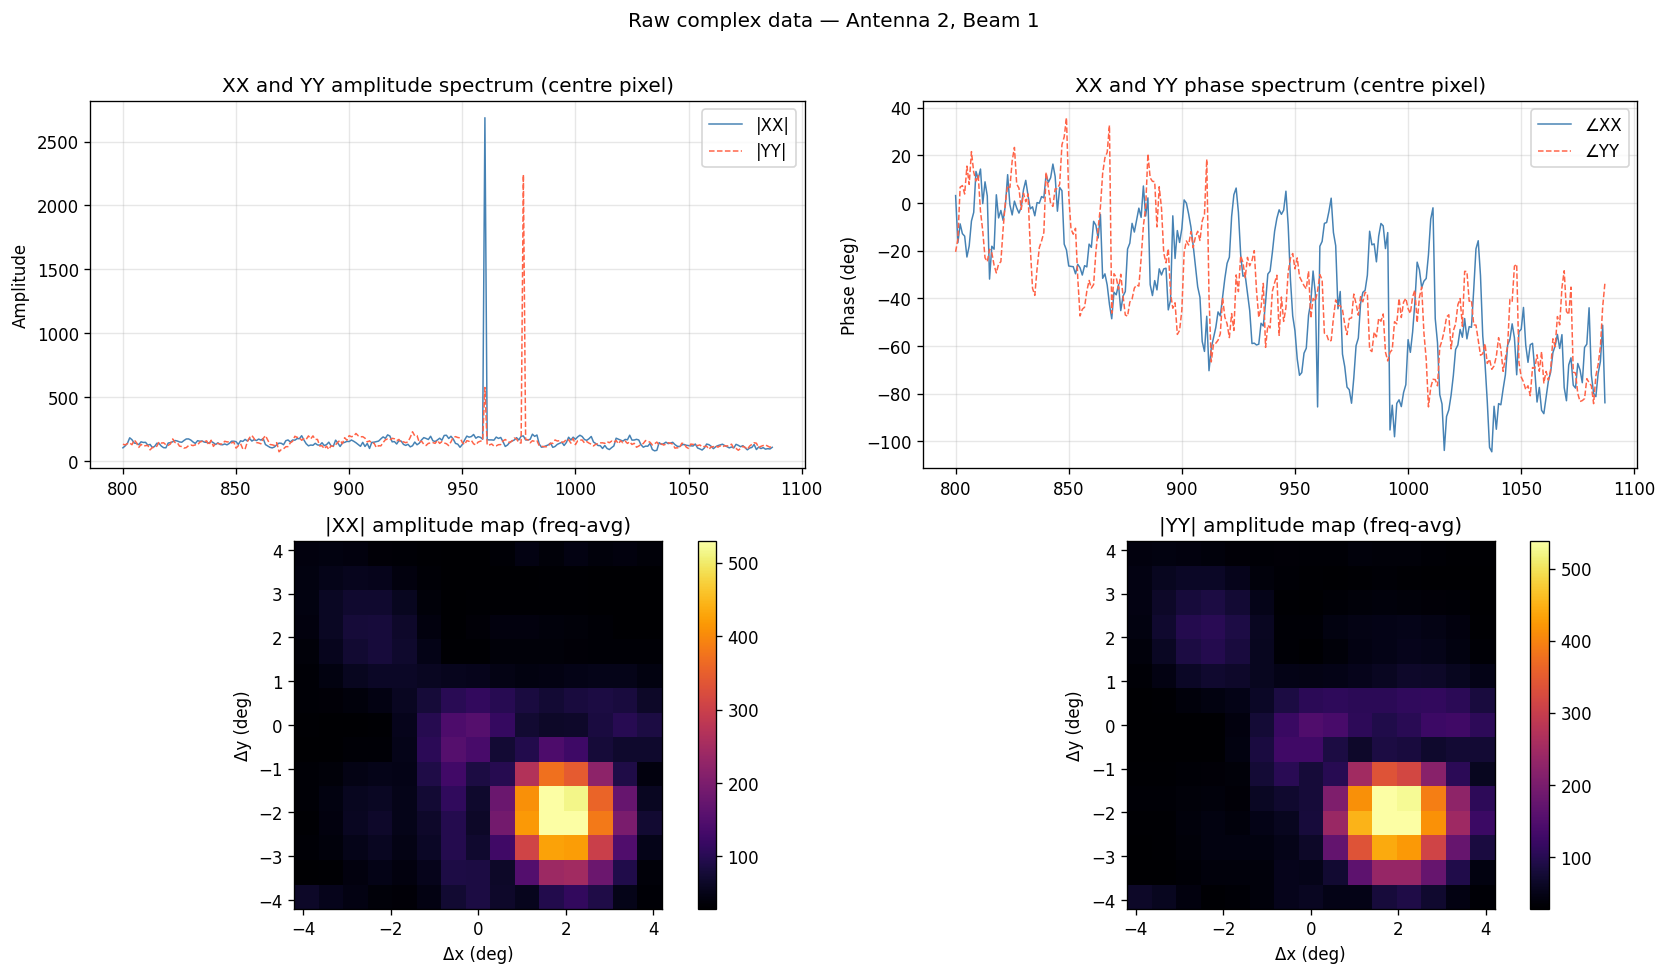

Mean |XX|/|YY| ratio at centre pixel : 1.0206  (1.0 = perfect balance)


In [15]:
# NOTE: antenna indices 0,2,6,9,18 are all-NaN — use any other index
ANT_IDX  = 1
BEAM_IDX = 0

with h5py.File(XXYY_FILE, 'r') as f:
    pols_xxyy = [p.decode() if isinstance(p, bytes) else p
                 for p in f['data'].attrs['polarizations']]  # ['XX','XY','YX','YY']
    xxyy_slice = f['data'][0, ANT_IDX, BEAM_IDX, :, :, :, :]  # (pol, freq, y, x)

XX = xxyy_slice[pols_xxyy.index('XX')]   # (freq, y, x)
YY = xxyy_slice[pols_xxyy.index('YY')]

# Centre pixel
cy, cx = NY//2, NX//2
xx_spec = XX[:, cy, cx]   # complex spectrum at centre pixel
yy_spec = YY[:, cy, cx]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Amplitude
axes[0, 0].plot(freqs_mhz, np.abs(xx_spec), lw=0.9, label='|XX|', color='steelblue')
axes[0, 0].plot(freqs_mhz, np.abs(yy_spec), lw=0.9, label='|YY|', color='tomato', ls='--')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].set_title('XX and YY amplitude spectrum (centre pixel)')
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

# Phase
axes[0, 1].plot(freqs_mhz, np.degrees(np.angle(xx_spec)), lw=0.9, label='∠XX', color='steelblue')
axes[0, 1].plot(freqs_mhz, np.degrees(np.angle(yy_spec)), lw=0.9, label='∠YY', color='tomato', ls='--')
axes[0, 1].set_ylabel('Phase (deg)')
axes[0, 1].set_title('XX and YY phase spectrum (centre pixel)')
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

# Frequency-averaged amplitude maps — robust colour scale
for ax_i, (data, label) in enumerate([(XX, 'XX'), (YY, 'YY')]):
    amp_map = np.abs(data).mean(axis=0)
    finite_amp = amp_map[np.isfinite(amp_map)]
    _av1, _av99 = np.nanpercentile(finite_amp, [1, 99])
    im = axes[1, ax_i].imshow(
        amp_map, origin='lower', cmap='inferno',
        extent=extent_deg, vmin=_av1, vmax=_av99
    )
    plt.colorbar(im, ax=axes[1, ax_i])
    axes[1, ax_i].set_title(f'|{label}| amplitude map (freq-avg)')
    axes[1, ax_i].set_xlabel('Δx (deg)')
    axes[1, ax_i].set_ylabel('Δy (deg)')

fig.suptitle(
    f'Raw complex data — Antenna {antennas[ANT_IDX]}, Beam {beams[BEAM_IDX]}',
    y=1.01
)
fig.tight_layout()
plt.show()

ratio = np.abs(xx_spec).mean() / np.abs(yy_spec).mean()
print(f'Mean |XX|/|YY| ratio at centre pixel : {ratio:.4f}  (1.0 = perfect balance)')
